#### Oliwia Obydź
### **Wycena nieruchomości na rynku wtórnym w województwie mazowieckim**

#### **1. Temat projektu**

Tematem projektu jest wycena nieruchomości na rynku wtórnym w województwie mazowieckim. Projekt oparty jest na danych z portalu otodom.pl. Głównym celem jest zbadanie wpływu parametrów technicznych oraz lokalizacji na wartość nieruchomości. Na ich podstawie zaimplementowany zostanie model uczenia maszynowego zdolny do estymowania cen, co pozwoli na weryfikację ofert rynkowych pod względem zawyżenia lub zaniżenia ceny.

#### **2. Skład zespołu**

Projekt indywidualny: Oliwia Obydź, numer albumu: 227758

#### **3. Opis zbioru danych**

**Źródło danych:** Dane zostały pozyskane metodą web scrapingu z polskiego portalu ogłoszeniowego z nieruchomościami otodom.pl w formacie .json oraz przetworzone w języku Python i wyeksportowane do formatu tabelarycznego.

**Liczba obserwacji i zmiennych:** Zbiór zawiera 1251 obserwacji i 13 zmiennych.

**Krótki opis zmiennych:**

Zmienne ciągłe:
1. cena - całkowita wartość nieruchomości (zł)
2. powierzchnia - metraż mieszkania (m2)
3. czynsz - opłata administracyjna
4. odległość - dystans od centrum Warszawy (km)

Zmienne dyskretne:
1. wiek - ilość lat od teraz do roku wybudowania budynku
2. pokoje - liczba pomieszczeń mieszkalnych
3. piętro - numer piętra, na którym znajduje się lokal
4. wysokość - całkowita liczba pięter w budynku

Zmienne kategoryczne:
1. miejscowość - lokalizacja nieruchomości
2. rodzaj zabudowy - typ budynku (np. mieszkanie w bloku, mieszkanie w kamienicy, apartament)
3. stan wykończenia - np. do zamieszkania, do remontu
4. rodzaj okien - np. drewniane, plastikowe
5. rodzaj ogrzewania - np. miejskie, gazowe, własne

**Problem do rozwiązania:** Problem regresji – zmienną docelową jest cena nieruchomości, ciągła wartość liczbowa.

**Cel biznesowy projektu:** Stworzenie modelu wyceniającego nieruchomości na rynku wtórnym na terenie województwa mazowieckiego, który może zostać wykorzystany przez agentów nieruchomości, prywatnych inwestorów, a także klientów indywidualnych. Głównym założeniem projektu jest minimalizacja strat i ochrona przed „zamrożeniem” oferty w przypadku sprzedających oraz zabezpieczenie przed przepłaceniem za nieruchomość w przypadku nabywców.


#### **4. Podstawowe informacje o zbiorze danych**

Wczytanie zbioru danych oraz zaimportowanie potrzebnych bibliotek:

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker

plt.style.use('seaborn-v0_8-pastel') 
mpl.rcParams.update({
    'axes.titlesize': 10,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10
})


df = pd.read_csv("dataset_csv.csv")
df

,cena,powierzchnia,wiek,czynsz,pokoje,piętro,wysokość budynku,odległość od centrum,miasto,zabudowa,wykończenie,okna,ogrzewanie
0,295000,54.26,73.0,686.0,2.0,1,3.0,91.95,Radom,blok,do remontu,plastikowe,miejskie
1,500000,27.76,55.0,300.0,1.0,5,10.0,3.79,Warszawa,blok,do zamieszkania,plastikowe,miejskie
2,790000,50.50,22.0,950.0,2.0,3,4.0,12.06,Warszawa,blok,do zamieszkania,plastikowe,miejskie
3,470000,32.50,27.0,NaN,1.0,2,3.0,12.02,Warszawa,blok,do zamieszkania,drewniane,miejskie
4,660000,41.23,3.0,750.0,2.0,parter,NaN,14.06,Ożarów Mazowiecki,blok,do zamieszkania,plastikowe,miejskie
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1246,790000,47.00,26.0,1200.0,2.0,4,11.0,5.40,Warszawa,blok,do wykończenia,NaN,NaN
1247,630000,58.50,50.0,1027.0,3.0,5,10.0,6.49,Warszawa,blok,do remontu,NaN,miejskie
1248,599000,36.70,62.0,600.0,2.0,2,4.0,2.42,Warszawa,blok,do zamieszkania,plastikowe,miejskie
1249,819000,53.70,65.0,873.0,3.0,7,7.0,3.63,Warszawa,blok,do remontu,NaN,miejskie


Liczebność zbioru danych oraz typy zmiennych:

In [2]:
size = df.shape[0]
print(f"Zbiór liczy {size} rekordów.")

Zbiór liczy 1251 rekordów.


In [3]:
types = pd.DataFrame({"Nazwa":df.columns, "Typ":df.dtypes, "Indeks":range(1, len(df.columns)+1)})
types_indexed = types.set_index("Indeks")
types_indexed

,Nazwa,Typ
Indeks,,
1,cena,int64
2,powierzchnia,float64
3,wiek,float64
4,czynsz,float64
5,pokoje,float64
6,piętro,str
7,wysokość budynku,float64
8,odległość od centrum,float64
9,miasto,str


Podstawowe statystyki dla zmiennych ciągłych:

In [4]:
pd.options.display.float_format = '{:.2f}'.format
statistics = df.describe()
statistics

,cena,powierzchnia,wiek,czynsz,pokoje,wysokość budynku,odległość od centrum
count,1251.00,1251.00,1167.00,1038.00,1250.00,1210.00,1251.00
mean,1105884.19,60.41,35.19,1075.42,2.59,6.17,12.31
std,900983.04,30.98,64.69,4749.78,0.95,4.19,20.38
min,145000.00,19.00,-78.00,1.00,1.00,1.00,0.19
25%,659000.00,42.59,10.00,650.00,2.00,4.00,3.92
50%,850000.00,53.73,24.00,820.00,2.00,5.00,6.34
75%,1218500.00,68.87,56.00,1088.00,3.00,8.00,10.09
max,12900000.00,440.28,2021.00,153179.00,7.00,52.00,108.04


#### **5. Walidacja danych**

##### **5.1 Ujemne wartości w kolumnie wiek**

Przede wszystkim możemy zaobserwować, że najmniejsza wartość w kolumnie *wiek* jest ujemna. Z tego powodu musimy przyjrzeć się tej kolumnie szerzej: sprawdzic czy ma więcej ujemnych wartości oraz je obsłużyć.

In [5]:
df[df["wiek"] < 0]

,cena,powierzchnia,wiek,czynsz,pokoje,piętro,wysokość budynku,odległość od centrum,miasto,zabudowa,wykończenie,okna,ogrzewanie
261,651280,46.52,-1.00,NaN,2.00,parter,2.00,13.01,Warszawa,blok,do wykończenia,plastikowe,miejskie
267,897328,65.98,-1.00,NaN,3.00,1,2.00,13.02,Warszawa,blok,do wykończenia,plastikowe,miejskie
715,820000,42.50,-78.00,695.00,2.00,parter,5.00,8.27,Warszawa,blok,do zamieszkania,plastikowe,miejskie


In [6]:
df = df.drop(index=715)

Usnęłam komórkę z nielogicznie dużą wartością. Wartości -1 pozostawiam, możemy domyślać się po stanie wykończenia *do wykończenia*, że są to mieszkania zaplanowane do budowy na przyszły rok.

##### **5.2 Zmienna piętro jako typ numeryczny**

Zmienna *piętro*, ze względu na obecność wartości opisowych została pierwotnie wczytana jako typ tekstowy. Zamienię *parter* na 0, *suterenę* na -1, natomiast wartości *poddasze* oraz *>10* na wysokość konkretnego budynku. Następnie przeprowadzę konwersję tej kolumny na typ numeryczny, aby włączyć ją w dalsze obliczenia statystyczne.

In [7]:
floor_mapping = {
    "parter":0,
    "suterena":-1}

df["piętro"] = df["piętro"].replace(floor_mapping)
df.loc[df["piętro"] == "> 10", "piętro"] = df["wysokość budynku"]
df.loc[df["piętro"] == "poddasze", "piętro"] = df["wysokość budynku"]
df["piętro"] = df["piętro"].astype(float)

In [8]:
df["piętro"].dtype

dtype('float64')

##### **5.3 Statystyki**

Jeszcze raz wyświetlam statystyki z poprawionymi wartościami *wieku* oraz dodaną kolumną *piętro*.

In [9]:
statistics = df.describe()
statistics

,cena,powierzchnia,wiek,czynsz,pokoje,piętro,wysokość budynku,odległość od centrum
count,1250.00,1250.00,1166.00,1037.00,1249.00,1240.00,1209.00,1250.00
mean,1106112.90,60.43,35.29,1075.79,2.59,3.25,6.17,12.32
std,901307.32,30.99,64.64,4752.06,0.95,3.73,4.19,20.39
min,145000.00,19.00,-1.00,1.00,1.00,-1.00,1.00,0.19
25%,659000.00,42.69,10.00,650.00,2.00,1.00,4.00,3.92
50%,850000.00,53.75,24.00,820.00,2.00,2.00,5.00,6.33
75%,1218750.00,68.94,56.00,1092.00,3.00,4.00,8.00,10.09
max,12900000.00,440.28,2021.00,153179.00,7.00,52.00,52.00,108.04


#### **6. Analiza wartości odstających**

W celu identyfikacji wartości odstających, użyję metody rozstępu ćwiartkowego (IQR). Zamiast jednak *ucinać* dane na sztywno, przeanalizuję najpierw te skrajne przypadki i usunę wiersze, które nie mają logicznego sensu z punktu widzenia rynku nieruchomości (np. skrajnie niska cena za mieszkanie).

In [10]:
def iqr(col):
    q1 = col.quantile(0.25)
    q3 = col.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr

    return lower, upper

##### **6.1 Cena**

In [11]:
price_iqr = iqr(df["cena"])
print(price_iqr[:2])

lower = df["cena"]<=price_iqr[0]
upper = df["cena"]>=price_iqr[1]

(np.float64(-180625.0), np.float64(2058375.0))


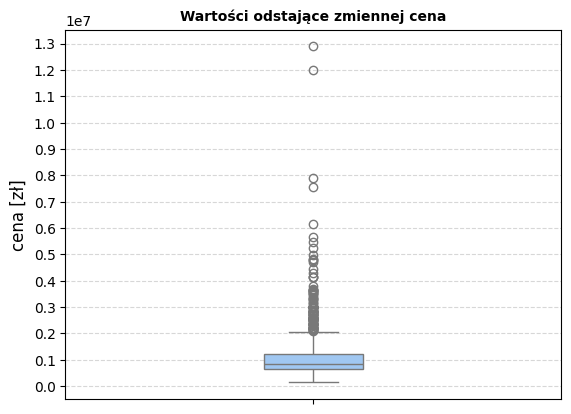

In [12]:
sns.boxplot(y=df["cena"], width=0.2)
plt.title("Wartości odstające zmiennej cena")
plt.yticks([i for i in range(0, 13000001, 1000000)])
plt.ylabel("cena [zł]")
plt.grid(visible=True, axis="y", linestyle="--", alpha=0.5)

Analiza wykresu ukazuje, że typowe ceny mieszkań oscylują wokół 1 mln zł. Górna granica typowych wartości wynosi ok. 2 mln zł. Widoczny jest bardzo długi *ogon* wartości odstających powyżej górnego wąsa oraz brak występowania wartości poniżej dolnego wąsa. Szczególną uwagę zwracają dwie skrajne wartości rzędu 12 i 13 mln zł. Mogą one wynikać z błędów przy wprowadzaniu danych lub dotyczyć wyjątkowo luksusowych nieruchomości, co zostanie poddane weryfikacji poniżej.

In [13]:
print("Liczba wartości odstających:", df.loc[lower | upper, "cena"].count())
df[lower | upper].sort_values("cena")

Liczba wartości odstających: 108


,cena,powierzchnia,wiek,czynsz,pokoje,piętro,wysokość budynku,odległość od centrum,miasto,zabudowa,wykończenie,okna,ogrzewanie
879,2100000,77.18,8.00,NaN,3.00,1.00,4.00,4.52,Warszawa,apartamentowiec,do zamieszkania,drewniane,NaN
1162,2120000,125.25,26.00,1500.00,5.00,1.00,4.00,6.34,Warszawa,apartamentowiec,do zamieszkania,plastikowe,kotłownia
720,2150000,91.30,16.00,1200.00,4.00,2.00,10.00,9.90,Warszawa,blok,do zamieszkania,drewniane,miejskie
220,2150000,125.00,90.00,1500.00,5.00,2.00,2.00,3.35,Warszawa,kamienica,do remontu,plastikowe,miejskie
1026,2150000,91.00,26.00,1300.00,3.00,1.00,6.00,5.19,Warszawa,apartamentowiec,do zamieszkania,plastikowe,miejskie
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,6150000,150.00,8.00,2900.00,5.00,14.00,14.00,1.05,Warszawa,apartamentowiec,do zamieszkania,drewniane,miejskie
995,7550000,207.00,3.00,2500.00,4.00,4.00,4.00,3.91,Warszawa,apartamentowiec,do wykończenia,drewniane,miejskie
341,7900000,342.55,15.00,5500.00,4.00,8.00,8.00,0.89,Warszawa,apartamentowiec,NaN,NaN,miejskie
725,11990000,271.00,5.00,4000.00,7.00,7.00,8.00,1.38,Warszawa,apartamentowiec,do zamieszkania,plastikowe,miejskie


Zgodnie z przypuszczeniami wysnutymi podczas analizy wykresu, skrajnie wysokie ceny obejmują mieszkania o powierzchni w setkach $m^2$, w nowych apartamentowcach, usytuowanych blisko centrum Warszawy. Są to jednak bardzo skrajne wartości i dotyczą zmiennej objaśnianej. Pomimo tego, że wyglądają całkowicie poprawnie, dla dobra modelu i niezaburzania dalszej analizy, postanowiłam je usunąć.

In [14]:
df = df.drop(index=[725, 846])

##### **6.2 Powierzchnia**

In [15]:
area_iqr = iqr(df["powierzchnia"])
print(area_iqr[:2])

lower = df["powierzchnia"]<=area_iqr[0]
upper = df["powierzchnia"]>=area_iqr[1]

(np.float64(3.5487500000000054), np.float64(107.75874999999999))


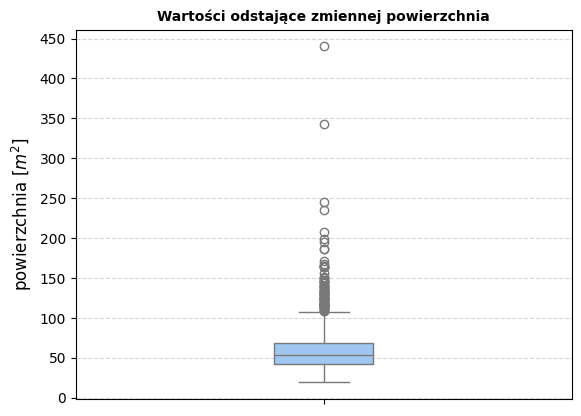

In [16]:
sns.boxplot(y=df["powierzchnia"], width=0.2)
plt.title("Wartości odstające zmiennej powierzchnia")
plt.yticks([i for i in range(0, 500, 50)])
plt.ylabel("powierzchnia [$m^2$]")
plt.grid(visible=True, axis="y", linestyle="--", alpha=0.5)

Typowa powierzchnia mieszkań mieści się w przedziale 40-70 $m^2$. Górna granica typowych wartości sięga lekko ponad 100 $m^2$. Podobnie jak w przypadku cen, widoczny jest wyraźny *ogon* górnych wartości odstających, przy jednoczesnym braku występowania anomalii poniżej dolnego wąsa. Powierzchnie rzędu kilkuset $m^2$ dotyczą najprawdopodobniej luksusowych apartamentów, co sprawdzę dokładnie w dalszej analizie.

In [17]:
print("Liczba wartości odstających: ", df.loc[lower | upper, "powierzchnia"].count())
df[lower | upper].sort_values("powierzchnia")

Liczba wartości odstających:  79


,cena,powierzchnia,wiek,czynsz,pokoje,piętro,wysokość budynku,odległość od centrum,miasto,zabudowa,wykończenie,okna,ogrzewanie
1098,1490000,108.19,30.00,1850.00,4.00,4.00,4.00,6.61,Warszawa,blok,do zamieszkania,plastikowe,miejskie
638,3258000,108.60,22.00,2600.00,3.00,5.00,7.00,3.54,Warszawa,apartamentowiec,do zamieszkania,NaN,miejskie
636,1810000,109.70,26.00,3200.00,3.00,3.00,11.00,7.89,Warszawa,apartamentowiec,do zamieszkania,plastikowe,miejskie
532,865000,111.00,1.00,NaN,5.00,1.00,2.00,14.90,Marki,blok,do wykończenia,plastikowe,inne
282,2900000,111.70,12.00,NaN,4.00,9.00,9.00,3.78,Warszawa,apartamentowiec,do zamieszkania,drewniane,miejskie
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,7550000,207.00,3.00,2500.00,4.00,4.00,4.00,3.91,Warszawa,apartamentowiec,do wykończenia,drewniane,miejskie
1179,5647680,235.32,19.00,2500.00,5.00,3.00,3.00,9.20,Warszawa,apartamentowiec,do zamieszkania,drewniane,miejskie
681,3200000,245.00,17.00,1388.00,5.00,3.00,3.00,10.24,Warszawa,apartamentowiec,do zamieszkania,aluminiowe,gazowe
341,7900000,342.55,15.00,5500.00,4.00,8.00,8.00,0.89,Warszawa,apartamentowiec,NaN,NaN,miejskie


In [18]:
print(round(3522240/440.28, 2))

8000.0


Analiza rekordu o największej powierzchni budzi wątpliwości. Cena na poziomie 3,5 mln zł przekłada się na zaledwie 8000 zł/1$m^2$, co przy lokalizacji oddalonej o 2,5 km od centrum Warszawy jest wartością rażąco niską. Nawet uwzględniając wiek i rodzaj budynku (100-letnia kamienica) oraz stan *do wykończenia*, oferta ta drastycznie odbiega od pozostałych odstających rekordów - dużych, luksusowych mieszkań w nowych apartamentowcach, które osiągają wielokrotnie wyższe ceny jednostkowe. Ze względu na wysokie ryzyko, że rekord ten stanowi błąd w danych lub dotyczy specyficznej formy własności (np. sprzedaży udziałów), usunę go z bazy.

In [19]:
df = df.drop(index=374)

##### **6.3 Wiek**

In [20]:
age_iqr = iqr(df["wiek"])
print(age_iqr[:2])

lower = df["wiek"]<=age_iqr[0]
upper = df["wiek"]>=age_iqr[1]

(np.float64(-59.0), np.float64(125.0))


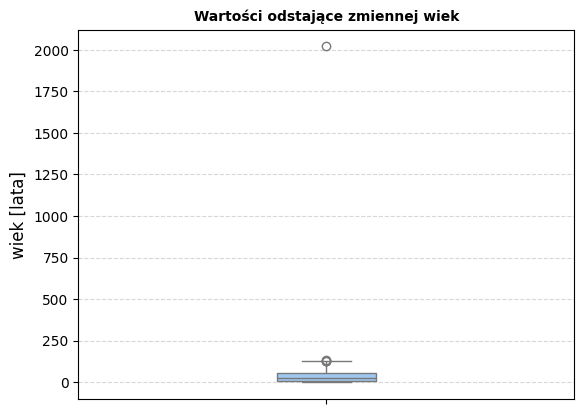

In [21]:
sns.boxplot(y=df["wiek"], width=0.2)
plt.title("Wartości odstające zmiennej wiek")
plt.ylabel("wiek [lata]")
plt.grid(visible=True, axis="y", linestyle="--", alpha=0.5)

Na wykresie wieku budynku widoczna jest jedna, ekstremalna wartość odstająca rzędu 2000 lat. Wynika ona ewidentnie z błędu wprowadzania danych – wiek został omyłkowo wpisany w rok budowy przez autora ogłoszenia. Oprócz tego, tuż powyżej górnego wąsa, występuje skupisko wartości wynoszących nieco ponad 100 lat. Mogą to być autentyczne, przedwojenne kamienice, co sprawdzę dokładnie poniżej, analizując całe rekordy. Obsrewujemy również brak występowania wartości poniżej dolnego wąsa.

In [22]:
print("Liczba wartości odstających: ", df.loc[lower | upper, "wiek"].count())
df[lower | upper].sort_values("wiek")

Liczba wartości odstających:  6


,cena,powierzchnia,wiek,czynsz,pokoje,piętro,wysokość budynku,odległość od centrum,miasto,zabudowa,wykończenie,okna,ogrzewanie
1073,1899000,68.00,125.00,700.00,3.00,2.00,6.00,0.99,Warszawa,kamienica,do wykończenia,plastikowe,miejskie
85,799000,46.67,126.00,890.00,2.00,1.00,4.00,1.06,Warszawa,kamienica,NaN,NaN,miejskie
979,2499000,99.30,126.00,1980.00,4.00,3.00,4.00,1.32,Warszawa,kamienica,do zamieszkania,drewniane,miejskie
167,1479000,55.00,126.00,720.00,3.00,2.00,5.00,0.66,Warszawa,kamienica,do zamieszkania,plastikowe,miejskie
598,350000,60.00,136.00,300.00,2.00,2.00,NaN,95.69,Płock,kamienica,do zamieszkania,plastikowe,inne
226,350000,30.00,2021.00,600.00,1.00,1.00,4.00,15.06,Pruszków,blok,do remontu,plastikowe,miejskie


Tak jak było to widoczne na wykresie, rekord o najwyższym wieku budynku ma nierealistyczną wartość 2021 lat. Ze względu na brak możliwości jednoznacznego ustalenia faktycznego wieku tej nieruchomości, usunę ten wiersz. Pozostałe wartości odstające (budynki mające 125–136 lat) są wiarygodne - tak jak zakładałam dotyczą zabytkowych kamienic.

In [23]:
df = df.drop(index=226)

##### **6.4 Czynsz**

In [24]:
rent_iqr = iqr(df["czynsz"])
print(rent_iqr[:2])

lower = df["czynsz"]<=rent_iqr[0]
upper = df["czynsz"]>=rent_iqr[1]

(np.float64(-7.0), np.float64(1745.0))


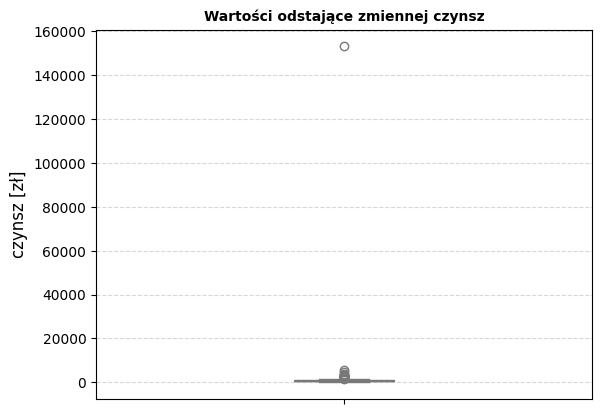

In [25]:
sns.boxplot(y=df["czynsz"], width=0.2)
plt.title("Wartości odstające zmiennej czynsz")
plt.ylabel("czynsz [zł]")
plt.grid(visible=True, axis="y", linestyle="--", alpha=0.5)

Podobnie jak w przypadku poprzedniej zmiennej, analiza wysokości czynszu ukazała jedną, skrajną wartość odstającą wynoszącą ok. 150 tyś. zł, która również najprawdopodobniej wynika z błędu wprowadzenia danych. Niestety drastycznie zaburza ona czytelność całego wykresu. Na ten moment nie stanowi to problemu, ponieważ zgodnie z przyjętym schematem, dla każdej zmiennej weryfikuję nietypowe rekordy bezpośrednio w ramce danych. 
Ponadto tutaj również obsrewujemy brak występowania wartości poniżej dolnego wąsa.

In [26]:
print("Liczba wartości odstających: ", df.loc[lower | upper, "czynsz"].count())
df[lower | upper].sort_values("czynsz")

Liczba wartości odstających:  54


,cena,powierzchnia,wiek,czynsz,pokoje,piętro,wysokość budynku,odległość od centrum,miasto,zabudowa,wykończenie,okna,ogrzewanie
1189,2590000,79.60,11.00,1750.00,3.00,1.00,7.00,1.76,Warszawa,apartamentowiec,NaN,NaN,miejskie
551,3650000,146.20,11.00,1760.00,5.00,4.00,4.00,8.98,Warszawa,apartamentowiec,do zamieszkania,NaN,miejskie
557,1999000,104.08,5.00,1776.00,5.00,4.00,6.00,7.56,Warszawa,blok,do zamieszkania,NaN,miejskie
459,2570000,96.80,11.00,1793.00,3.00,4.00,4.00,8.55,Warszawa,blok,do zamieszkania,drewniane,miejskie
642,2190000,116.00,19.00,1800.00,4.00,3.00,7.00,4.59,Warszawa,blok,do zamieszkania,plastikowe,miejskie
697,2600000,89.76,10.00,1800.00,4.00,1.00,5.00,1.97,Warszawa,apartamentowiec,do zamieszkania,drewniane,miejskie
904,1850000,97.50,10.00,1800.00,4.00,1.00,5.00,6.76,Warszawa,blok,do zamieszkania,plastikowe,miejskie
481,2990000,81.00,1.00,1800.00,3.00,6.00,28.00,1.61,Warszawa,apartamentowiec,do zamieszkania,aluminiowe,miejskie
978,2800000,122.00,99.00,1800.00,4.00,4.00,4.00,3.16,Warszawa,kamienica,do zamieszkania,drewniane,inne
1180,3650000,122.00,6.00,1800.00,5.00,4.00,4.00,8.73,Warszawa,apartamentowiec,do zamieszkania,plastikowe,miejskie


Na pewno pozbędę się omawianego już rekordu o najwyższym czynszu. Pozostałe wartości są realistyczne: dotyczną lokali o powierzchni w setkach $m^2$ w nowoczesnych apartamentowcach albo dotyczną dużych mieszkań w prestiżowych, przedwojennych kamienicach w centrum Warszawy.

In [27]:
df = df.drop(index=813)

##### **6.5 Pokoje**

In [28]:
rooms_iqr = iqr(df["pokoje"])
print(rooms_iqr[:2])

lower = df["pokoje"]<=rooms_iqr[0]
upper = df["pokoje"]>=rooms_iqr[1]

(np.float64(0.5), np.float64(4.5))


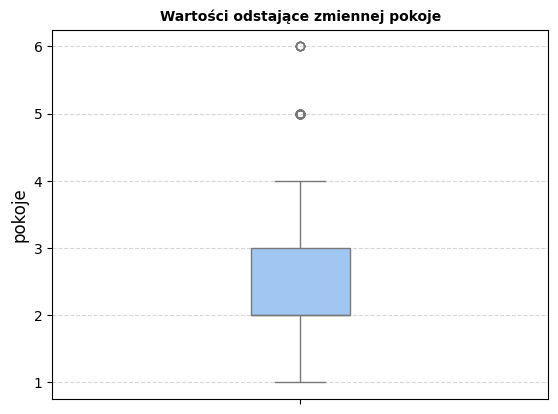

In [29]:
sns.boxplot(y=df["pokoje"], width=0.2)
plt.title("Wartości odstające zmiennej pokoje")
plt.grid(visible=True, axis="y", linestyle="--", alpha=0.5)

Wykres pokazuje, że typowa liczba pokoi to 2-3. Górna granica standardowych wartości wynosi 4, a dolna 1. Wśród wartości odstających najwięcej jest mieszkań 5-pokojowych, następnie 6-pokojowych, a największa liczba pokoi w analizowanej bazie to 7. Dolne wartości odstające nie występują, co jest w pełni logiczne (brak możliwości wystąpienia nieruchomości o liczbie pokoi mniejszej niż 1).

In [30]:
print("Liczba wartości odstających: ", df.loc[lower | upper, "pokoje"].count())
df[lower | upper].sort_values("pokoje")

Liczba wartości odstających:  39


,cena,powierzchnia,wiek,czynsz,pokoje,piętro,wysokość budynku,odległość od centrum,miasto,zabudowa,wykończenie,okna,ogrzewanie
5,1199900,125.20,5.00,NaN,5.00,1.00,2.00,15.03,Kobyłka,apartamentowiec,do zamieszkania,plastikowe,gazowe
43,2200000,139.70,26.00,NaN,5.00,1.00,2.00,6.95,Warszawa,blok,do zamieszkania,plastikowe,miejskie
130,2570000,128.00,47.00,1900.00,5.00,3.00,7.00,2.16,Warszawa,blok,do zamieszkania,NaN,miejskie
205,1299000,114.30,28.00,NaN,5.00,2.00,2.00,10.11,Warszawa,blok,NaN,plastikowe,miejskie
220,2150000,125.00,90.00,1500.00,5.00,2.00,2.00,3.35,Warszawa,kamienica,do remontu,plastikowe,miejskie
304,1635000,115.20,27.00,2115.00,5.00,3.00,4.00,4.86,Warszawa,blok,do zamieszkania,plastikowe,NaN
370,3790000,194.50,30.00,4000.00,5.00,3.00,6.00,7.55,Warszawa,apartamentowiec,do zamieszkania,drewniane,miejskie
375,3290000,140.00,17.00,2250.00,5.00,2.00,2.00,9.73,Warszawa,apartamentowiec,do zamieszkania,drewniane,miejskie
521,540000,100.00,66.00,NaN,5.00,2.00,2.00,92.45,Radom,kamienica,do remontu,plastikowe,gazowe
388,5240000,163.80,17.00,3000.00,5.00,4.00,6.00,1.73,Warszawa,apartamentowiec,do zamieszkania,NaN,miejskie


Wiekszość rekordów o liczbie pokoi powyżej 4 jest wiarygodnych - to mieszkania o dużej powierzchni (100-300$m^2$). Uwagę zwracają jednak ogłoszenia oferujące 5 lub więcej pokoi na metrażu rzędu 50–70 $m^2$. Takie parametry mogą sugerować specyficzne nieruchomości przygotowane pod wynajem, gdzie przestrzeń została maksymalnie podzielona. Aby zweryfikować rynkową zasadność tych danych i ich wpływ na model, przeanalizuję średni metraż przypadającego na jeden pokój.

In [31]:
rooms_outliers = df.loc[[619,527,412,499,916], ["powierzchnia", "pokoje"]]
rooms_outliers["średni metraż"] = rooms_outliers["powierzchnia"] / rooms_outliers["pokoje"]
rooms_outliers

,powierzchnia,pokoje,średni metraż
619,67.00,5.00,13.40
527,67.00,5.00,13.40
412,68.74,5.00,13.75
499,58.10,6.00,9.68
916,63.30,6.00,10.55


Istnieje ryzyko, że w tych rekordach liczba pokoi nie obejmuje kuchni i łazienki. Nawet jeśli to realne oferty pod wynajem, ich skrajnie niski metraż na pokój jest nietypowy dla rynku. Aby nie zaburzać korelacji w modelu i uniknąć błędnych danych, zdecyduje sie na ich usunięcie.

In [32]:
df = df.drop(index=[619,527,412,499,916])

##### **6.6 Piętro**

In [33]:
floor_iqr = iqr(df["piętro"])
print(floor_iqr[:2])

lower = df["piętro"]<=floor_iqr[0]
upper = df["piętro"]>=floor_iqr[1]

(np.float64(-3.5), np.float64(8.5))


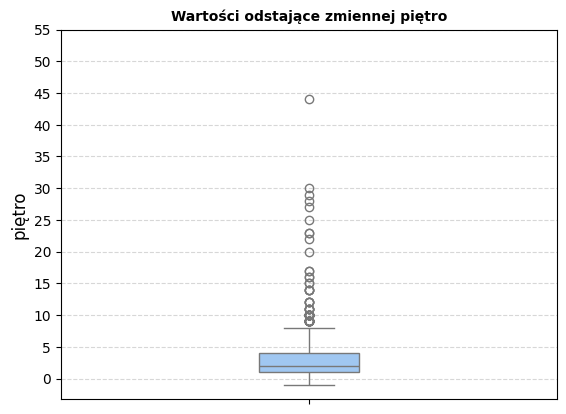

In [34]:
sns.boxplot(y=df["piętro"], width=0.2)
plt.title("Wartości odstające zmiennej piętro")
plt.yticks([i for i in range(0, 60, 5)])
plt.grid(visible=True, axis="y", linestyle="--", alpha=0.5)

Dominująca część mieszkań w bazie znajduje się w niskiej zabudowie - do 4 pięter. Obecne są liczne górne wartości odstające i brak odchyleń w dolnym zakresie. Mimo że metoda IQR wskazuje wartości odstające już od 9. piętra, bloki o wysokości nawet 15–20 pięter są standardem na wielu miejskich osiedlach. Dwie największe wartości (44. i 52. piętro) są całkowicie realne jak na standardy warszawskiego rynku premium, co jeszcze zostanie dokładnie zweryfikowane poniżej.

In [35]:
print("Liczba wartości odstających: ", df.loc[lower | upper, "piętro"].count())
df[lower | upper].sort_values("piętro")

Liczba wartości odstających:  68


,cena,powierzchnia,wiek,czynsz,pokoje,piętro,wysokość budynku,odległość od centrum,miasto,zabudowa,wykończenie,okna,ogrzewanie
13,650000,62.50,56.00,NaN,3.00,9.00,10.00,5.83,Warszawa,blok,do remontu,plastikowe,miejskie
96,750000,54.00,55.00,945.00,3.00,9.00,10.00,4.07,Warszawa,blok,do remontu,plastikowe,miejskie
190,749999,45.30,50.00,817.00,2.00,9.00,10.00,7.04,Warszawa,blok,do zamieszkania,plastikowe,miejskie
183,799000,48.60,58.00,900.00,3.00,9.00,10.00,8.37,Warszawa,blok,do zamieszkania,plastikowe,miejskie
154,920000,53.00,28.00,800.00,2.00,9.00,11.00,4.82,Warszawa,apartamentowiec,NaN,drewniane,miejskie
...,...,...,...,...,...,...,...,...,...,...,...,...,...
202,1790000,72.00,3.00,850.00,2.00,27.00,27.00,3.53,Warszawa,apartamentowiec,do zamieszkania,NaN,miejskie
1035,1297000,35.90,1.00,NaN,1.00,28.00,28.00,1.58,Warszawa,apartamentowiec,do zamieszkania,aluminiowe,miejskie
1149,1591000,37.00,2.00,NaN,1.00,29.00,29.00,1.60,Warszawa,apartamentowiec,do zamieszkania,NaN,NaN
987,795000,36.20,21.00,1000.00,1.00,30.00,30.00,1.23,Warszawa,blok,do zamieszkania,plastikowe,miejskie


Tak jak założyłam przy analizie wykresu, mieszkania usytuowane na 30., 40. lub nawet 50. piętrze to apartamenty w nowych, luskusowych wieżowcach mieszkalnych. Dane te są rynkowo poprawne, dlatego zdecydowałam się o zachowaniu wszystkich rekordów.

##### **6.7 Liczba pięter budynku**

In [36]:
total_floors_iqr = iqr(df["wysokość budynku"])
print(total_floors_iqr[:2])

lower = df["wysokość budynku"]<=total_floors_iqr[0]
upper = df["wysokość budynku"]>=total_floors_iqr[1]

(np.float64(-2.0), np.float64(14.0))


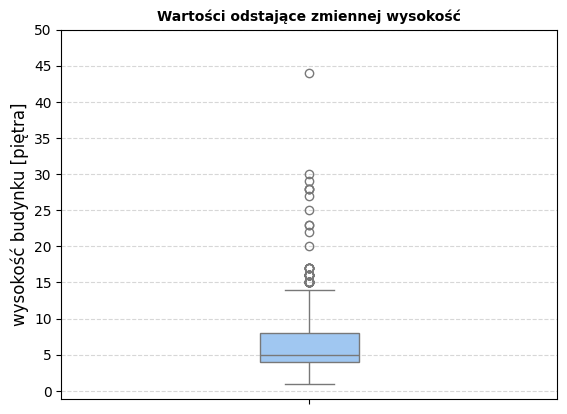

In [37]:
sns.boxplot(df["wysokość budynku"], width=0.2)
plt.title("Wartości odstające zmiennej wysokość")
plt.ylabel("wysokość budynku [piętra]")
plt.yticks([i for i in range(0, 55, 5)])
plt.grid(visible=True, axis="y", linestyle="--", alpha=0.5)

Większość budynków osiąga wysokość rzędu 4-8 pięter. Górna granica typowych wartości to 14 pięter. Widać wiele wartości odstających powyżej górnego wąsa i brak wartości poniżej dolnego wąsa. Analogicznie do zmiennej *piętro*, skrajne wartości rzędu kilkudziesięciu pięter mogą dotyczyć warszawskich apartamentowców, co również szczegółowo sprawdzę w dalszej analizie.

In [38]:
print("Liczba wartości odstających: ", df.loc[lower | upper, "wysokość budynku"].count())
df[lower | upper].sort_values("wysokość budynku")

Liczba wartości odstających:  57


,cena,powierzchnia,wiek,czynsz,pokoje,piętro,wysokość budynku,odległość od centrum,miasto,zabudowa,wykończenie,okna,ogrzewanie
313,1242000,46.00,17.00,NaN,2.00,3.00,14.00,0.59,Warszawa,apartamentowiec,do zamieszkania,drewniane,miejskie
448,770000,36.07,60.00,630.00,2.00,14.00,14.00,1.95,Warszawa,blok,do zamieszkania,plastikowe,inne
402,4825000,112.24,8.00,NaN,4.00,14.00,14.00,1.02,Warszawa,apartamentowiec,do zamieszkania,aluminiowe,miejskie
397,869000,43.50,14.00,900.00,2.00,2.00,14.00,3.49,Warszawa,apartamentowiec,do zamieszkania,drewniane,miejskie
1195,6150000,150.00,8.00,2900.00,5.00,14.00,14.00,1.05,Warszawa,apartamentowiec,do zamieszkania,drewniane,miejskie
902,950000,54.80,16.00,960.00,2.00,14.00,14.00,6.75,Warszawa,blok,do zamieszkania,drewniane,miejskie
150,1195000,65.74,19.00,1100.00,3.00,1.00,15.00,5.87,Warszawa,apartamentowiec,do zamieszkania,drewniane,miejskie
45,1199000,49.00,54.00,1250.00,3.00,1.00,15.00,0.89,Warszawa,blok,do zamieszkania,plastikowe,miejskie
595,599000,27.40,54.00,650.00,1.00,15.00,15.00,0.58,Warszawa,blok,do remontu,NaN,miejskie
621,840000,56.80,43.00,857.00,3.00,6.00,15.00,6.27,Warszawa,blok,do zamieszkania,plastikowe,miejskie


Potwierdza się to samo co w przypadku wartości odstających zmiennej *piętro* - budynki o wysokości 15–20 pięter są standardem, natomiast obiekty w przedziale 20–50 pięter to autentyczne apartamentowce w centrum Warszawy. Tutaj również zdecydowałam się o zachowaniu wszystkich rekordów.

##### **6.8 Odległość od centrum Warszawy**

In [39]:
distance_iqr = iqr(df["odległość od centrum"])
print(distance_iqr[:2])

lower = df["odległość od centrum"]<=distance_iqr[0]
upper = df["odległość od centrum"]>=distance_iqr[1]

(np.float64(-5.338749999999999), np.float64(19.35125))


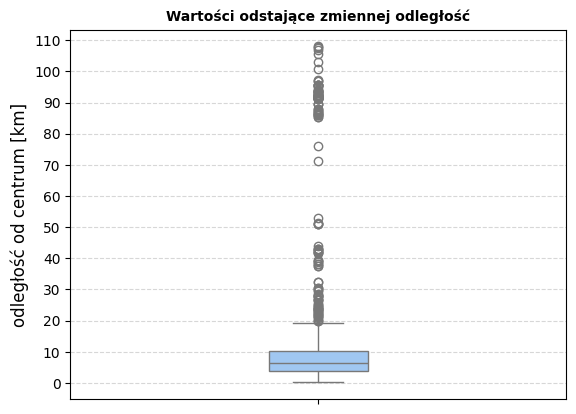

In [40]:
sns.boxplot(df["odległość od centrum"], width=0.2)
plt.title("Wartości odstające zmiennej odległość")
plt.ylabel("odległość od centrum [km]")
plt.yticks([i for i in range(0, 111, 10)])
plt.grid(visible=True, axis="y", linestyle="--", alpha=0.5)

Analiza wykresu pokazuje, że większość mieszkań jest usytuowanych w promieniu do 10 km od centrum Warszawy, co oznacza, że znajdują się one w granicach miasta. Widoczny jest bardzo długi *ogon* powyżej górnego wąsa, co jest jednak całkowicie uzasadnione, ponieważ analizie poddane są wszystkie nieruchomości w województwie mazowieckim. Brak występowania wartości pod dolnym wąsem (ok. 0 km) jest logiczny, gdyż odległość nie może przyjmować wartości ujemnych.

In [41]:
print("Liczba wartości odstających: ", df.loc[lower | upper, "odległość od centrum"].count())
df[lower | upper].sort_values("odległość od centrum")

Liczba wartości odstających:  132


,cena,powierzchnia,wiek,czynsz,pokoje,piętro,wysokość budynku,odległość od centrum,miasto,zabudowa,wykończenie,okna,ogrzewanie
808,450000,46.25,NaN,600.00,3.00,3.00,4.00,19.72,Legionowo,blok,do remontu,plastikowe,miejskie
251,175000,21.00,87.00,170.00,1.00,2.00,2.00,19.98,Wołomin,kamienica,do remontu,plastikowe,elektryczne
483,660000,47.00,20.00,NaN,3.00,1.00,3.00,20.29,Wołomin,blok,do zamieszkania,plastikowe,gazowe
298,650000,55.00,0.00,NaN,2.00,0.00,1.00,20.74,Legionowo,apartamentowiec,do wykończenia,plastikowe,gazowe
300,800000,59.49,6.00,950.00,3.00,4.00,4.00,21.06,Brwinów,blok,do zamieszkania,NaN,inne
...,...,...,...,...,...,...,...,...,...,...,...,...,...
924,409000,72.90,26.00,773.00,3.00,2.00,3.00,105.46,Mława,blok,do zamieszkania,plastikowe,kotłownia
601,459000,60.45,15.00,318.00,4.00,1.00,3.00,106.97,Mława,blok,do zamieszkania,plastikowe,gazowe
494,495000,50.20,2.00,450.00,2.00,4.00,4.00,107.38,Mława,blok,do zamieszkania,plastikowe,gazowe
237,499000,60.64,9.00,NaN,3.00,1.00,4.00,107.73,Mława,blok,do zamieszkania,plastikowe,gazowe


Analiza pełnych rekordów potwierdza wnioski z wykresu - wartości odstające dla *odległości od centrum* dotyczą lokali położonych poza granicami Warszawy. Ich autentyczność dodatkowo potwierdzają adekwatnie niższe ceny rynkowe. Ponieważ rekordy te są całkowicie poprawne i odzwierciedlają realne zróżnicowanie lokalizacji w zbiorze, jak najbardziej pozostawiam je w bazie.

#### **7. Analiza brakujących wartości**

Identyfikacja kolumn z brakującymi wartościami oraz ich udział procentowy:

In [42]:
missing_vals = df.isnull().sum()
missing_vals_df = pd.DataFrame({"braki":missing_vals})
missing_vals_df["% udział"] = missing_vals_df["braki"]/size * 100
missing_vals_df

,braki,% udział
cena,0,0.00
powierzchnia,0,0.00
wiek,84,6.71
czynsz,211,16.87
pokoje,0,0.00
piętro,10,0.80
wysokość budynku,41,3.28
odległość od centrum,0,0.00
miasto,0,0.00
zabudowa,0,0.00


Dla przypomnienia oraz dalszej analizy wyświetlimy jeszcze raz podstawowe statystyki (już bez wartości odstających).

In [43]:
statistics = df.describe()
statistics

,cena,powierzchnia,wiek,czynsz,pokoje,piętro,wysokość budynku,odległość od centrum
count,1240.00,1240.00,1156.00,1029.00,1240.00,1230.00,1199.00,1240.00
mean,1086356.36,59.85,33.54,925.72,2.57,3.21,6.14,12.38
std,777706.79,28.36,28.12,470.00,0.92,3.47,3.99,20.46
min,145000.00,19.00,-1.00,1.00,1.00,-1.00,1.00,0.19
25%,659000.00,42.50,10.00,650.00,2.00,1.00,4.00,3.92
50%,849950.00,53.55,24.00,820.00,2.00,2.00,5.00,6.34
75%,1202500.00,68.54,56.00,1070.00,3.00,4.00,8.00,10.09
max,7900000.00,342.55,136.00,5500.00,6.00,44.00,44.00,108.04


##### **7.1 Wiek**

Braki w kolumnie *wiek* stanowią niecałe 7% wartości zmiennej. Uzupełnię je na podstawie średniego wieku dla każdego rodzaju zabudowy.

In [44]:
df["wiek"].isnull().sum()

np.int64(84)

In [45]:
df.loc[df["wiek"].isnull(), "zabudowa"].value_counts()

zabudowa
blok               60
apartamentowiec    12
kamienica          12
Name: count, dtype: int64

In [46]:
df.groupby("zabudowa")["wiek"].mean().round(0)

zabudowa
apartamentowiec   11.00
blok              33.00
kamienica         84.00
Name: wiek, dtype: float64

In [47]:
df["wiek"] = df["wiek"].fillna(df.groupby("zabudowa")["wiek"].transform("mean").round(0))

In [48]:
df["wiek"].isnull().sum()

np.int64(0)

##### **7.2 Czynsz**

Braki w kolumnie *czynsz* stanowią prawie 17% wartości zmiennej. Aby uzupełnić te dane w sposób logiczny i niezaburzający dalszej analizy, wykorzystam dostępne dane o powierzchni nieruchomości, zachowując proporcję pomiędzy wielkością mieszkania, a jego kosztami administracyjnymi. Wyznaczam współczynnik *factor*, reprezentujący średni czynsz na $1 m^2$.

In [49]:
factor = (df["czynsz"]/df["powierzchnia"]).mean()
factor

np.float64(16.004897436922445)

*Factor* wynosi ok. 16 zł za $1 m^2$. 
W kolejnym kroku uzupełnię brakujące wartości w kolumnie *czynsz*, mnożąc ten współczynnik przez powierzchnię danej nieruchomości.

In [50]:
df.loc[df["czynsz"].isnull(), "czynsz"] = df.loc[df["czynsz"].isnull(), "powierzchnia"] * factor

In [51]:
df["czynsz"].isnull().sum()

np.int64(0)

##### **7.3 Piętro**

Braki w kolumnie *piętro* stanowią niespełna 1% wartości zmiennej. Ze względu na znikomy udział, zdecydowałam o ich uzupełnięniu medianą, co pozwoli zachować kompletność zbioru bez ryzyka zniekształcenia danych.

In [52]:
floor_median = df["piętro"].median()
floor_median

np.float64(2.0)

In [53]:
df["piętro"] = df["piętro"].fillna(floor_median)

In [54]:
df["piętro"].isnull().sum()

np.int64(0)

##### **7.4 Wysokość budynku**

Braki w kolumnie *wysokość budynku* stanowią lekko ponad 3% wartości zmiennej. Uzupełnie je średnią wartością tej kolumny dla rodzaju zabudowy. Dodatkowo wprowadzę jednak warunek korygujący: w przypadkach, gdy przypisana mediana będzie niższa niż wartość w kolumnie *piętro*, wysokość budynku zrównam z kondygnacją lokalu.

In [55]:
df.loc[df["wysokość budynku"].isnull(), "zabudowa"].value_counts()

zabudowa
blok               29
apartamentowiec     7
kamienica           5
Name: count, dtype: int64

In [56]:
df.groupby("zabudowa")["wysokość budynku"].mean().round(0)

zabudowa
apartamentowiec   7.00
blok              6.00
kamienica         4.00
Name: wysokość budynku, dtype: float64

In [57]:
df["wysokość budynku"] = df["wysokość budynku"].fillna(df.groupby("zabudowa")["wysokość budynku"].transform("mean").round(0))

In [58]:
df["wysokość budynku"].isnull().sum()

np.int64(0)

##### **7.5 Wykończenie**

Braki w kolumnie wykończenie stanowią ok. 8% wartości zmiennej. Uzupełniłam je najczęstszą wartością z całego zbioru, czyli modą. Przy tak małym odsetku braków to w pełni bezpieczne rozwiązanie.

In [59]:
df["wykończenie"].value_counts()

wykończenie
do zamieszkania    905
do remontu         144
do wykończenia      89
Name: count, dtype: int64

In [60]:
condition_mode = df["wykończenie"].mode()[0]
condition_mode

'do zamieszkania'

In [61]:
df["wykończenie"] = df["wykończenie"].fillna(condition_mode)

In [62]:
df["wykończenie"].isnull().sum()

np.int64(0)

##### **7.6 Okna**

In [63]:
windows_and_age_sorted = df[["wiek", "okna"]].sort_values("wiek")

In [64]:
windows_and_age_sorted.head(200)["okna"].value_counts()

okna
plastikowe    123
drewniane      20
aluminiowe      2
Name: count, dtype: int64

In [65]:
windows_and_age_sorted.tail(200)["okna"].value_counts()

okna
plastikowe    114
drewniane      27
Name: count, dtype: int64

Ze względu na wysoki odsetek braków danych (28%) oraz brak wiarygodnej metody ich estymacji, kolumna *okna* zostanie całkowicie usunięta ze zbioru. Wstępna analiza nie wykazuje wyraźnej zależności między rodzajem okien a wiekiem budynku. W starszych budynkach drewniane okna są masowo wymieniane na plastikowe (PCV), podczas gdy w nowych inwestycjach klasy premium często powraca się do okien drewnianych. Chociaż widać, że na rynku dominują okna plastikowe, odgórne uzupełnienie tą wartością blisko jednej trzeciej bazy sztucznie zniekształciłoby dane.

In [66]:
df = df.drop("okna", axis=1)

##### **7.7 Ogrzewanie**

In [67]:
df["ogrzewanie"].value_counts()

ogrzewanie
miejskie       992
gazowe          86
kotłownia       42
inne            28
elektryczne      7
Name: count, dtype: int64

In [68]:
df.groupby("zabudowa")["ogrzewanie"].describe()["top"]

zabudowa
apartamentowiec    miejskie
blok               miejskie
kamienica          miejskie
Name: top, dtype: object

In [69]:
df.groupby(pd.qcut(df['wiek'], q=4), observed=False)["ogrzewanie"].describe()["top"]

wiek
(-1.001, 11.0]    miejskie
(11.0, 26.0]      miejskie
(26.0, 55.25]     miejskie
(55.25, 136.0]    miejskie
Name: top, dtype: object

Podobnie jak w przypadku zmiennej *okna*, estymacja rodzaju ogrzewania na podstawie innych zmiennych okazała się trudna, ponieważ na analizowanym rynku dominuje ogrzewanie miejskie. Jednak w przeciwieństwie do stolarki okiennej, braki danych w kolumnie ogrzewanie stanowią zaledwie 6%, dlatego uzupełnie je najczęściej występującą wartością (modą).

In [70]:
heating_mode = df["ogrzewanie"].mode()[0]
heating_mode

'miejskie'

In [71]:
df["ogrzewanie"] = df["ogrzewanie"].fillna(heating_mode)

In [72]:
df["ogrzewanie"].isnull().sum()

np.int64(0)

#### **8. Wizualizacja danych**

##### **8.1 Histogramy dla zmiennych ilościowych**

In [73]:
def plots(df, var, f1, f2, **kwargs):
    plt.figure(figsize=(f1,f2))
    ax = sns.histplot(data=df, x=var, **kwargs)
    if ax.lines:
        ax.lines[0].set_color("#416787")
    plt.ylabel("częstość")
    plt.axvline(np.mean(df[var]), color="#D55E00", linewidth=2, linestyle="--", label="średnia")
    plt.axvline(np.median(df[var]), color="#CC0000", linewidth=2, linestyle="--", label="mediana")
    textstr = f"Średnia: {np.mean(df[var]):.2f}\nMediana: {np.median(df[var]):.2f}\nStd: {np.std(df[var]):.2f}"
    ax.text(0.8, 0.98, textstr, transform=ax.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='#c8e2ff', alpha=0.8))
    plt.legend(loc="upper right")

###### **8.1.1 Cena**

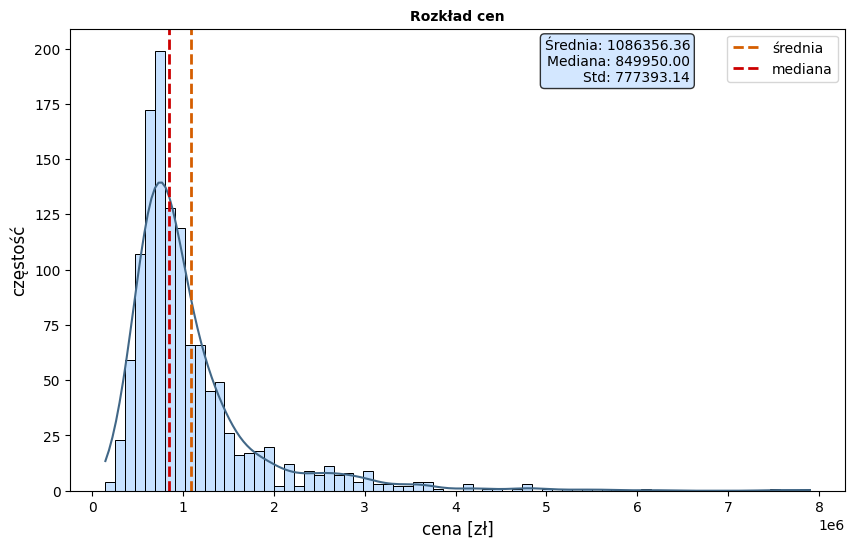

In [74]:
plots(df, "cena", 10, 6, kde=True)
plt.title("Rozkład cen")
plt.xlabel("cena [zł]")
plt.ylabel("częstość")
plt.show()

Rozkład cen jest silnie prawoskośny, co pokazuje, że większość mieszkań z badanego zbioru mieści się w niższych przedziałach cenowych (do ok. 1,2 mln zł). Widoczny długi prawy *ogon* oznacza, że pojawiają się pojedyncze, wyjątkowo drogie nieruchomości. Mocno zniekształcają one ogólny obraz, ponieważ sztucznie *ciągną* średnią w górę. Można założyć, że gdyby nie te wartości odstające, średnia cena rynkowa byłaby zauważalnie niższa. Z tego względu znacznie lepszą miarą tendencji centralnej – odporniejszą na skrajne odchylenia – jest w tym przypadku mediana, która wynosi 850 tys. zł. Dodatkowo odchylenie standardowe jest bardzo wysokie i stanowi prawie 82% średniej, co wskazuje na ogromne zróżnicowanie cen nieruchomości.

###### **8.1.2 Powierzchnia**

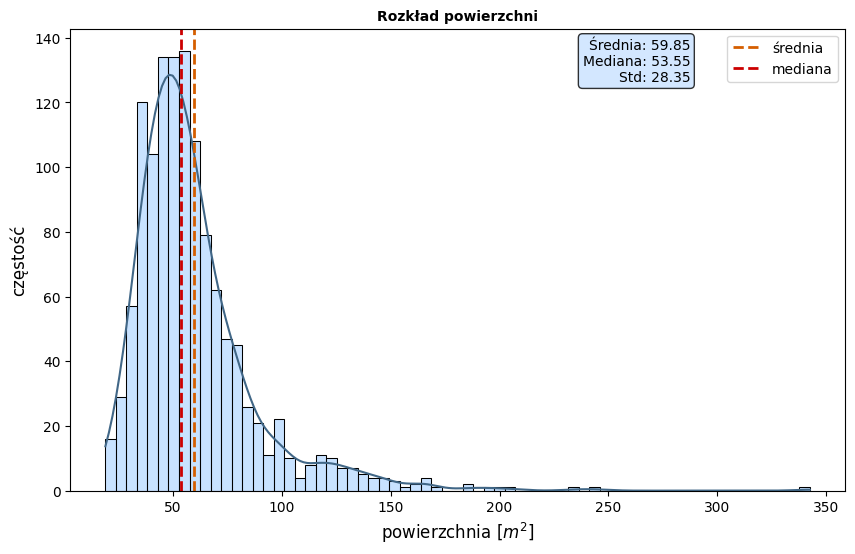

In [75]:
plots(df, "powierzchnia", 10, 6, kde=True)
plt.title("Rozkład powierzchni")
plt.xlabel("powierzchnia [$m^2$]")
plt.ylabel("częstość")
plt.show()

Podobnie jak w przypadku cen, rozkład powierzchni jest silnie prawoskośny. Pokazuje to, że metraż większości mieszkań mieści się w niższych wartościach (w przedziale 30-80 $m^2$). Długi prawy ogon na wykresie oznacza występowanie nielicznych, wyjątkowo dużych mieszkań - najprawdopodobniej luksusowych apartamentów. Analogicznie do poprzedniej zmiennej, te wartości odstające sztucznie zawyżają średnią, jednak nie zniekształca to obrazu tak drastycznie, jak w przypadku cen (różnica między medianą a średnią wynosi ok. 6,5 $m^2$). Odchylenie standardowe jest wysokie i stanowi prawie połowę średniej, co wskazuje na duże zróżnicowanie powierzchni lokali w zbiorze.

###### **8.1.3 Wiek**

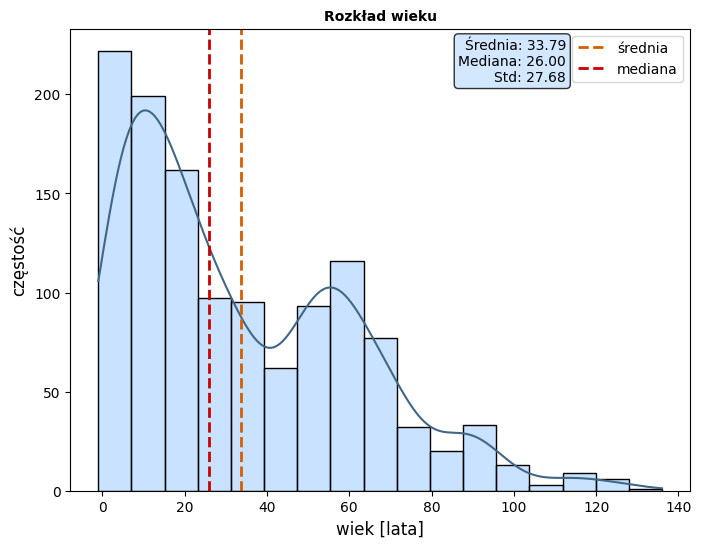

In [76]:
plots(df, "wiek", 8, 6, kde=True)
plt.title("Rozkład wieku")
plt.xlabel("wiek [lata]")
plt.ylabel("częstość")
plt.show()

Rozkład wieku jest prawoskośny. Widzimy, że największą część badanego zbioru stanowią mieszkania stosunkowo młode (do 20 lat). Można jednak zaobserwować dużą grupę budynków wybudowanych 50-70 lat temu. Wykres pokazuje też lekki wzrost w okolicy 90 lat - są to najprawdopodobniej przedwojenne kamienice. Krzywa opada o wiele łagodniej niż w dwóch poprzednich przypadkach, co wskazuje na mniejszą liczbę wartości odstających (pokrywa się to z poprzednią analizą, gdzie zidentyfikowałam ich tylko 6). Z tego powodu możemy uznać, że średnia (34 lata) jest bardziej miarodajna niż wcześniej, ale wciąż pozostaje nieco zawyżona względem mediany (26 lat). Odchylenie standardowe jest bardzo wysokie i stanowi prawie 82% średniej, co wskazuje na ogromne zróżnicowanie wieku analizowanych budynków.

###### **8.1.4 Czynsz**

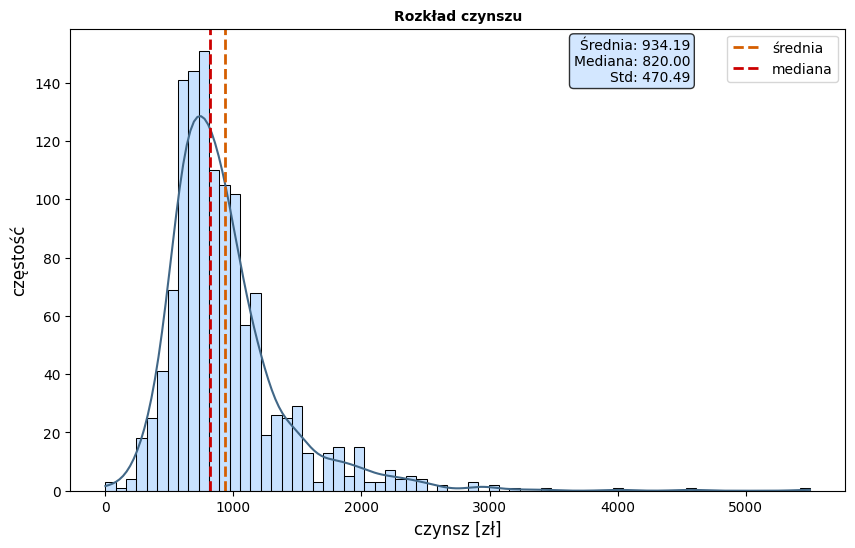

In [77]:
plots(df, "czynsz", 10, 6, kde=True)
plt.title("Rozkład czynszu")
plt.xlabel("czynsz [zł]")
plt.ylabel("częstość")
plt.show()

Rozkład czynszu jest silnie prawoskośny. Widać, że zdecydowana większość opłat administracyjnych mieści się w przedziale 500-1000 zł. Ponownie możemy zauważyć długi prawy *ogon*, oznaczający pojedyncze nieruchomości o wyjątkowo wysokim czynszu. Wskutek tego średnia jest wyższa od mediany o blisko 120 zł. Choć na rynku zdarzają się niższe opłaty, największe zagęszczenie wartości przypada na przedział 600–800 zł. Odchylenie standardowe stanowi lekko ponad połowę średniej (ok. 51%), co wskazuje na duże zróżnicowanie czynszu w badanym zbiorze.

###### **8.1.5 Pokoje**

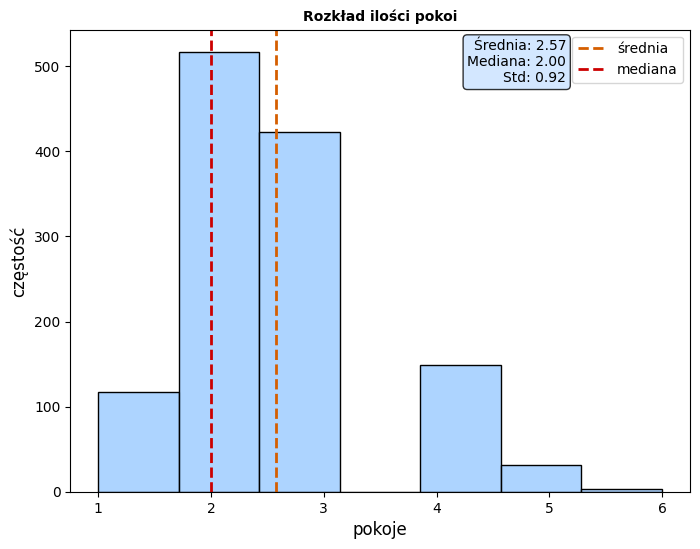

In [78]:
plots(df, "pokoje", 8, 6, bins=7)
plt.title("Rozkład ilości pokoi")
plt.xlabel("pokoje")
plt.ylabel("częstość")
plt.show()

Rozkład ilości pokoi również jest prawoskośny. Nie mamy tutaj jednak bardzo skrajnych wartości odstających - najwyższa zanotowana wartość to 7 pokoi. Średnia (2,58) nadal jest lekko zawyżona względem mediany (2,00), jednak trafnie wskazuje na przedział między 2 a 3 pokojami, co idealnie pokrywa się z największym zagęszczeniem na wykresie. Odchylenie standardowe wynosi niespełna 1 pokój, co stanowi tylko ok. 36% średniej. Pokazuje to, że w przeciwieństwie do pozostałych zmiennych, zróżnicowanie nieruchomości pod względem ilości pokoi nie jest aż tak duże.

###### **8.1.6 Piętro**

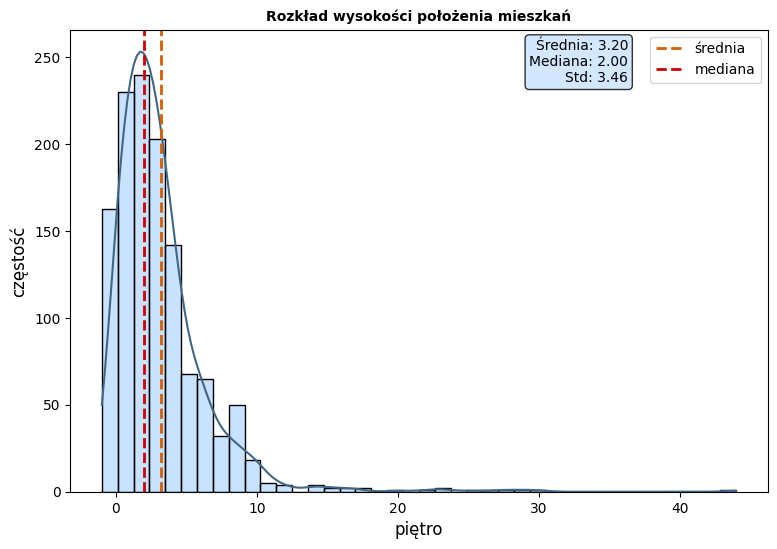

In [79]:
plots(df, "piętro", 9, 6, bins=40, kde=True)
plt.title("Rozkład wysokości położenia mieszkań")
plt.xlabel("piętro")
plt.ylabel("częstość")
plt.show()

Rozkład wysokości położenia mieszkań jest silnie prawoskośny, co pokazuje, że większość lokali mieści się w niższym przedziale (do 10. piętra). W badanym zbiorze dominują nisko położone mieszkania - największe zagęszczenie przypada na wartości od -1. (sutereny) do 4. piętra. Podobnie jak w przypadku innych zmiennych, pojawia się długi prawy *ogon*, co oznacza rzadkie występowanie bardzo wysoko położonych lokali. Średnia wysokość mieszkania to ok. 3. piętro, a mediana przypada na 2. piętro - różnica między tymi miarami nie jest więc tak drastyczna. Warto jednak zaznaczyć, że odchylenie standardowe jest wyższe od średniej, co potwierdza ogromne zróżnicowanie położenia nieruchomości w analizowanym zbiorze.

###### **8.1.7 Wysokość budynku**

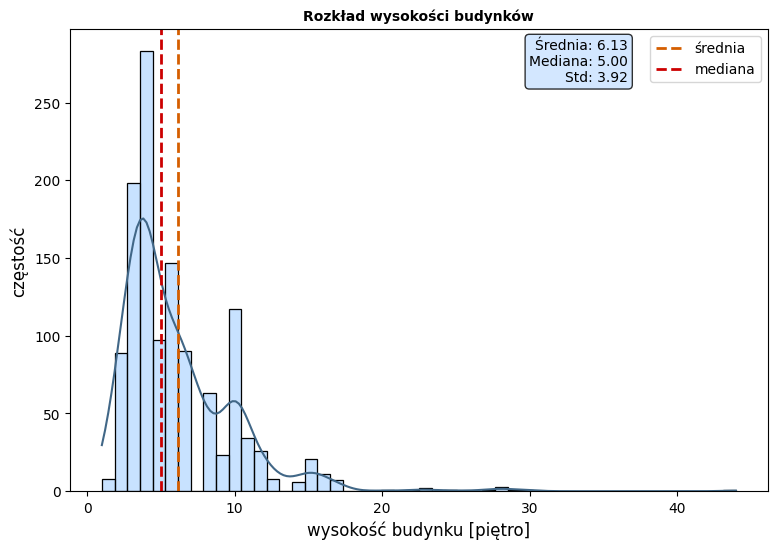

In [80]:
plots(df, "wysokość budynku", 9, 6, bins=50, kde=True)
plt.title("Rozkład wysokości budynków")
plt.xlabel("wysokość budynku [piętro]")
plt.ylabel("częstość")
plt.show()

Bardzo podobnie jak w przypadku wysokości położenia mieszkań, rozkład wysokości całych budynków jest silnie prawoskośny. W badanym zbiorze największe zagęszczenie przypada na niską zabudowę (do 6 pięter), przy czym widać zauważalny spadek liczebności w przypadku budynków 4-piętrowych. Wykres pokazuje również wyraźny, drugi szczyt w okolicach 10 pięter, co odzwierciedla obecność standardowych, wysokich bloków. Analogicznie do poprzedniej zmiennej, długi prawy *ogon* oznacza występowanie pojedynczych, bardzo wysokich budynków - najprawdopodobniej apartamentowców. Różnica między średnią (6-piętrowce) i medianą (5-piętrowce) jest tutaj niewielka. Odchylenie standardowe stanowi jednak aż 67% wartości średniej, pokazując duże zróżnicowanie wysokości analizowanych budynków.

###### **8.1.8 Odległość od centrum**

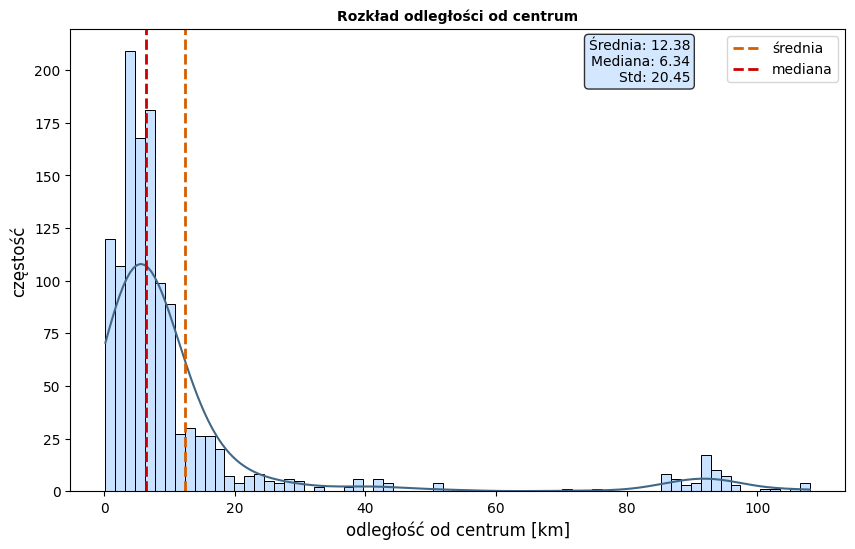

In [81]:
plots(df, "odległość od centrum", 10, 6, kde=True)
plt.title("Rozkład odległości od centrum")
plt.xlabel("odległość od centrum [km]")
plt.ylabel("częstość")
plt.show()

Rozkład odległości od centrum jest również silnie prawoskośny. Widać, że zdecydowana większość lokali mieści się w promieniu 10 km od centrum, czyli w granicach Warszawy. Mniejsza, ale nadal znacząca liczba nieruchomości (z wyraźną tendencją spadkową) roziąga się w przedziale 12-20 km. Dalej można zauważyć nieliczne lokale oddalone do ok. 50 km. Uwagę zwraca wyraźny, ponowny wzrost w okolicach 90 km od centrum Warszawy. Ze względu na te skrajne wartości, średnia (12,4 km) jest mocno zawyżona względem mediany (6,3 km). Odchylenie standardowe stanowi ok. 165% wartości średniej. W przypadku tej zmiennej jest to jednak całkowicie uzasadnione - analizie poddane są nieruchomości w całym województwie mazowieckim.

##### **8.2 Wykresy słupkowe dla zmiennych jakościowych**

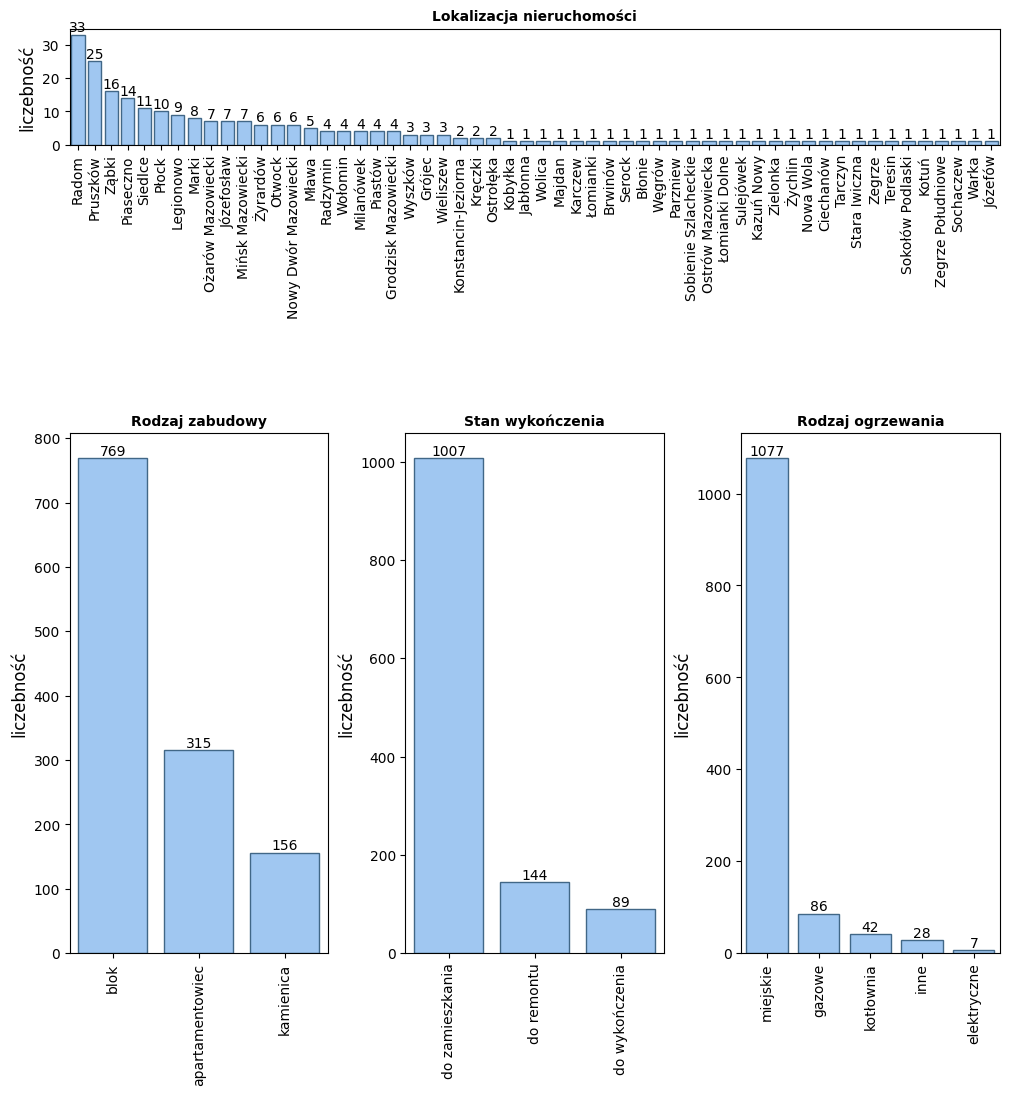

In [82]:
df_temp = df[df["miasto"] != "Warszawa"]
fig = plt.figure(figsize=(12,12))

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=2.5, wspace=0.3)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1:, 0])
ax3 = fig.add_subplot(gs[1:, 1])
ax4 = fig.add_subplot(gs[1:, 2])

sns.countplot(data=df_temp, x="miasto", order=df_temp["miasto"].value_counts().index, ax=ax1, edgecolor="#416787")
ax1.set_title("Lokalizacja nieruchomości")
ax1.set_xlabel("")
ax1.set_ylabel("liczebność")
ax1.tick_params(axis="x", rotation=90)
for container in ax1.containers:
    ax1.bar_label(container)

sns.countplot(data=df, x="zabudowa", order=df["zabudowa"].value_counts().index, ax=ax2, edgecolor="#416787")
ax2.set_title("Rodzaj zabudowy")
ax2.set_xlabel("")
ax2.set_ylabel("liczebność")
ax2.tick_params(axis="x", rotation=90)
for container in ax2.containers:
    ax2.bar_label(container)

sns.countplot(data=df, x="wykończenie", order=df["wykończenie"].value_counts().index, ax=ax3, edgecolor="#416787")
ax3.set_title("Stan wykończenia")
ax3.set_xlabel("")
ax3.set_ylabel("liczebność")
ax3.tick_params(axis="x", rotation=90)
for container in ax3.containers:
    ax3.bar_label(container)

sns.countplot(data=df, x="ogrzewanie", order=df["ogrzewanie"].value_counts().index, ax=ax4, edgecolor="#416787")
ax4.set_title("Rodzaj ogrzewania")
ax4.set_xlabel("")
ax4.set_ylabel("liczebność")
ax4.tick_params(axis="x", rotation=90)
for container in ax4.containers:
    ax4.bar_label(container)

plt.show()

W zestawieniu lokalizacji celowo pominęłam Warszawę, aby uniknąć zaburzenia czytelności wykresu przez jej dominujący udział. 
Najwyższą liczbą ofert wyróżnia się Radom (33 oferty), jako drugie największe miasto na Mazowszu. Tuż za nim odznaczają się miejscowości na obrzeżach stolicy, takie jak Pruszków, Ząbki czy Piaseczno. Na kolejnych miejscach widać inne większe miasta - Siedlce (11) oraz Płock (10). Prawa strona wykresu charakteryzuje się długim, płaskim *ogonem*, który obrazuje duże rozproszenie geograficzne w bazie (małe miejscowości posiadają po 1-2 rekordy).

Drugi wykres przedstawia strukturę rodzaju zabudowy. Tutaj zdecydowanie dominują bloki (796 ofert), których jest ponad dwukrotnie więcej niż apartamentowców (317). Najmniejszą grupę stanowią kamienice (156), na co wpływ może mieć to, że Warszawa uległa ogromnym zniszczeniom podczas wojny. Widać, że starsze budowle są zastępowane przez nowoczesne apartamentowce.

Analizując przedostatni wykres, można zauważyć, że obecnie na rynku dominują mieszkania gotowe do zamieszkania (1009 ofert). Jest ich aż 7-krotnie więcej od lokali do remontu i ponad 11-krotnie więcej od lokali do wykończenia. Może to sugerować, że wyremontowanie mieszkania przed sprzedażą generuje większy zarobek, niż sprzedawanie mieszkania w stanie deweloperskim/do remontu po niższej cenie. Z drugiej strony, może być to też zasługa zwykłej rotacji, kiedy ludzie sprzedają swoje dotychczasowe, już urządzone mieszkania, decydując się na zakup czegoś nowego.

W przypadku rodzaju ogrzewania widać dominację ogrzewania miejskiego (1079 ofert). Jest to w pełni logiczne, ponieważ przez ostatnie lata odchodzi się od instalacji gazowych na rzecz bezpieczeństwa i wygody, a w budynkach powyżej 25 metrów wysokości są one całkowicie zakazane. Można również zauważyć, że ogrzewanie elektryczne stanowi zaledwie 7 ofert, czego przyczyną mogą być wysokie rachunki za prąd oraz trudność w ogrzaniu całego budynku (wymaga to ogromnej mocy przyłączeniowej).

##### **8.3 Macierz korelacji pomiędzy zmiennymi ilościowymi**

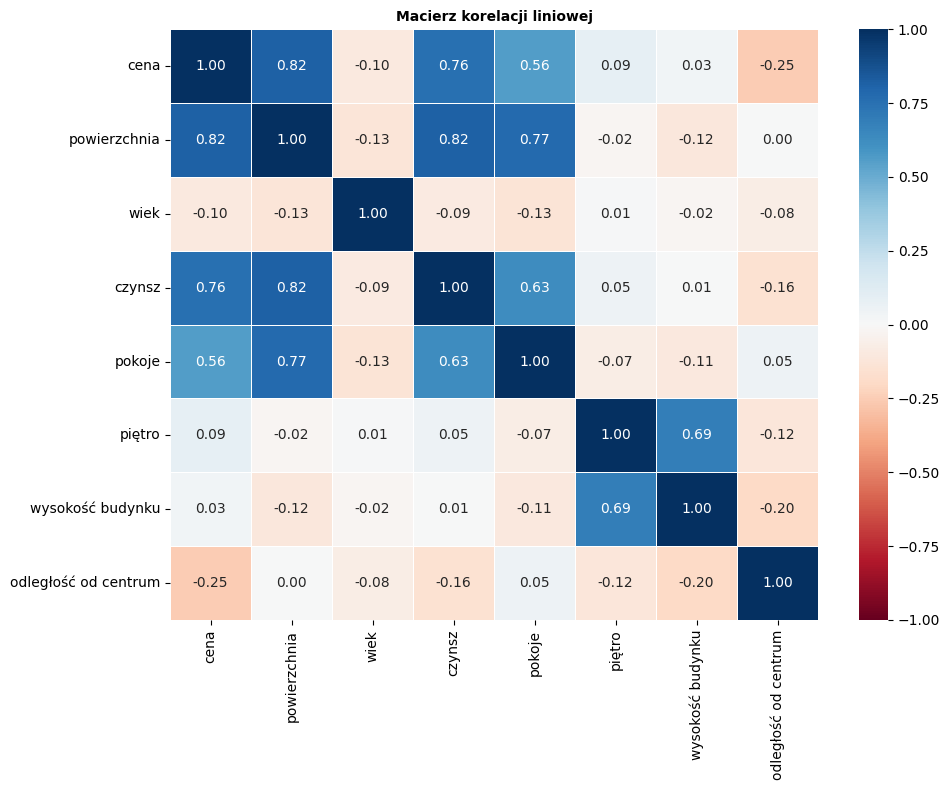

In [83]:
corr = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, vmin=-1, vmax=1,  linewidths=0.5, linecolor="white", fmt=".2f", cmap="RdBu")
plt.title("Macierz korelacji liniowej")
plt.tight_layout()
plt.show()

Powyższa mapa cieplna obrazuje współczynniki korelacji liniowej Pearsona pomiędzy badanymi zmiennymi. Najsilniejszą, dodatnią korelację w całym zbiorze wykazują powierzchnia lokalu oraz wysokość czynszu (0.82) oraz powierzchnia lokalu i jego cena (0.82). Dużą współzależność widać również pomiędzy powierzchnią a liczbą pokoi (0.77) i między ceną a czynszem (0.76). Możemy wnioskować, że zbiór danych opiera się na wyraźnym bloku czterech zmiennych: powierzchnia, pokoje, cena i czynsz, które w największym stopniu na siebie oddziałują.

Można zauważyć również silną korelację piętra z wysokością budynku (0.69), która jest jednak naturalna (wysokie piętra występują w wysokich budynkach). W przypadku zmiennej odległości od centrum, jej korelacje z innymi zmiennymi są słabe, a także wykazują ujemny kierunek względem ceny (-0.25) i czynszu (-0.16). Potwierdza to, że im dalej od Śródmieścia, tym koszty zakupu i najmu spadają.

Jeśli chodzi natomiast o korelacje bardzo słabe lub praktycznie niewystępujące, dotyczą one przede wszystkim zmiennej wiek, która nie wykazuje istotnego liniowego związku z żadnym z pozostałych parametrów. Odległość od centrum nie ma żadnego wpływu na wielkość lokalu (korelacja wynosi 0). Z kolei parametry takie jak wysokość budynku czy konkretne piętro, nie wykazują powiązania z wielkością mieszkania i mają niewielki wpływ na jego ostateczną cenę.

##### **8.4 Wykresy zależności między zmiennymi objaśniającymi a zmienną objaśnianą**

###### **8.4.1 Zmienne ilościowe**

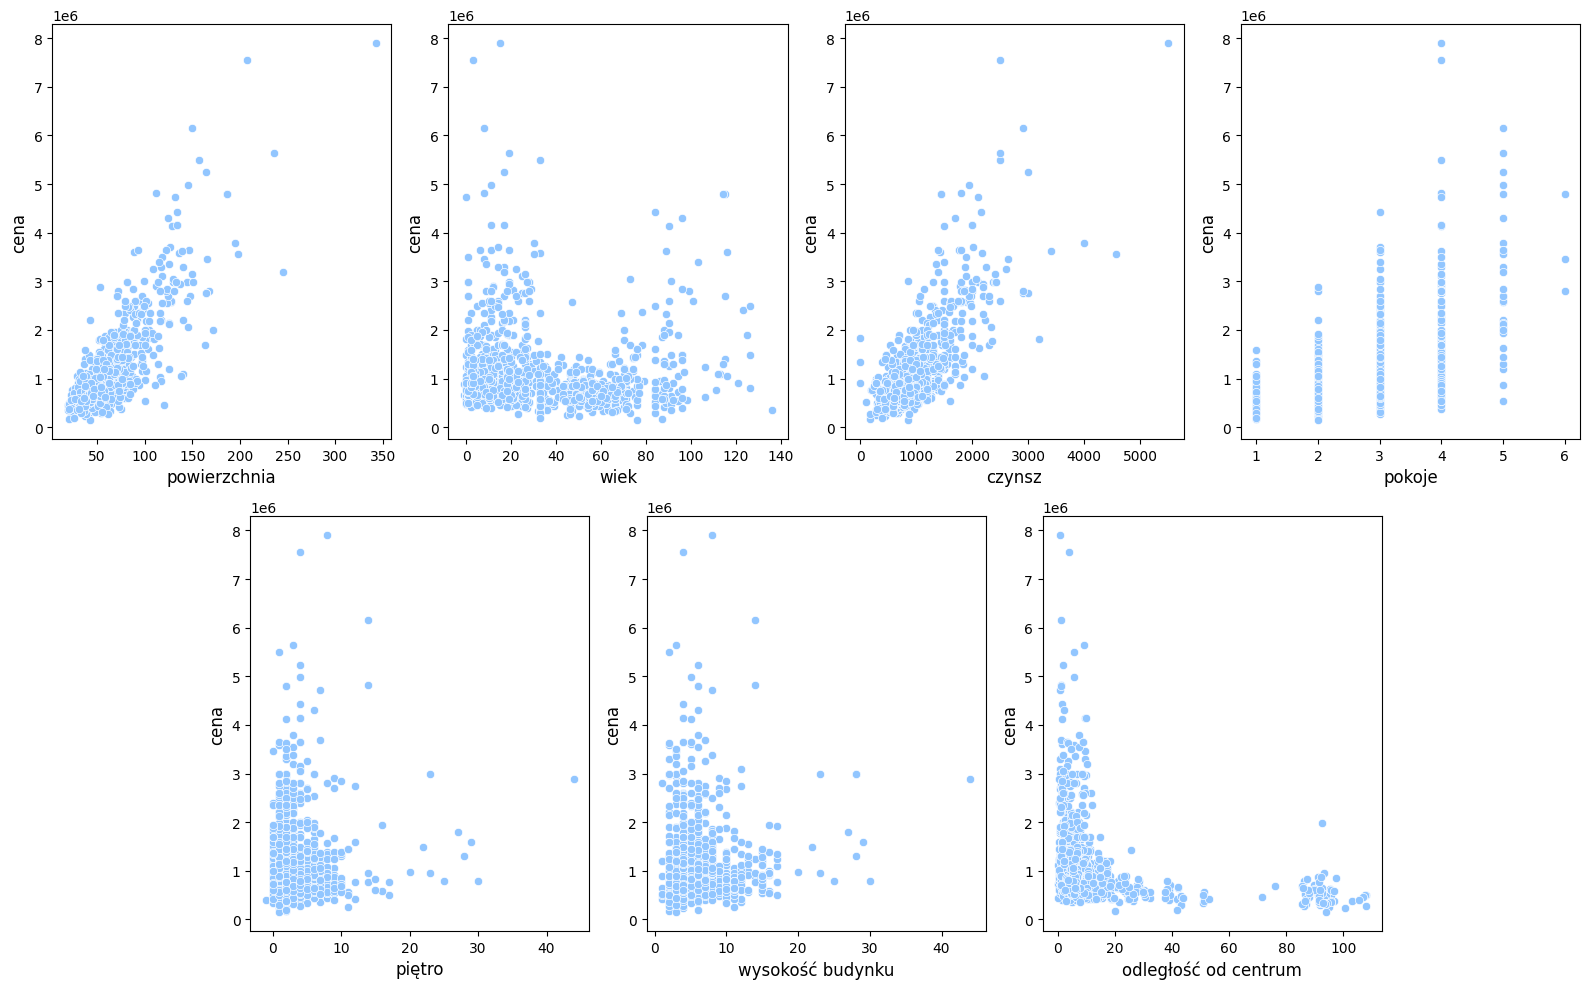

In [84]:
layout = """
AABBCCDD
.EEFFGG.
"""

fig, axes = plt.subplot_mosaic(layout, figsize=(16,10))

keys = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

for i in range(0, 7):
    ax = axes[keys[i]]
    sns.scatterplot(df, x=df.columns[i+1], y="cena", ax=ax)

plt.tight_layout()

Na pierwszy rzut oka widać, że pomiędzy ceną a powierzchnią oraz ceną a czynszem zachodzi wyraźny, dodatni trend liniowy, co pokrywa się z wnioskami wysuniętymi przy analizie mapy cieplnej. Oznacza to, że wraz ze wzrostem tych zmiennych, rośnie też cena nieruchomości.

Zależność między ceną a wiekiem budynku wykazała najmniejszą korelację liniową spośród wszystkich badanych cech. Można zauważyć jednak inne zjawisko. Najniższe i najbardziej ujednolicone ceny dotyczą budynków mających około 40–80 lat (prawdopodobnie bloki z czasów PRL). Z kolei największy rozstrzał i wzrost cenowy widać zarówno dla najnowszego budownictwa (nowoczesne apartamentowce) i budynków stuletnich (odrestaurowane, zabytkowe kamienice).

Liczba pokoi jest zmienną dyskretną, która w badanym zbiorze przyjmuje wartości tylko od 1 do 7, z tego powodu wykres układa się w pionowe słupki. Można tu zauważyć dodatni trend przy przechodzeniu z 1 do 3 pokoi, który dalej zanika na rzecz rozrzutu cenowego.

W przypadku relacji ceny z piętrem oraz ceny z wysokością budynku, największe zagęszczenie ofert występuje dla najniżych wartości obu zmiennych. Co ciekawe, widać, że najdroższe nieruchomości znajdują się przeważnie w niższym budownictwie (do ok. 15 pięter). Z kolei na bardzo wysokich piętrach (w wieżowcach) brakuje tanich mieszkań, co pokrywa się z realiami rynkowymi.

Jeśli chodzi o cenę i odległość od centrum, wyraźnie widać nieliniową zależność – początkowo ceny drastycznie spadają w miarę oddalania się od Śródmieścia. Na wykresie widać jednak ponowny, delikatny wzrost wartości w odległości około 80–100 km, co wskazuje na rynki nieruchomości wokół innych, większych miast Mazowsza.

###### **8.4.2 Zmienne jakościowe**

Aby przedstawić ogólny wpływ zmiennych jakościowych na zmienną objaśniającą, zastosuję logarytmiczną skalę dla osi rzędnych. W przypadku zwykłej skali, ekstremalne wartości odstające wymuszają nienaturalne rozciągnięcie osi Y, co zaburza proporcje pudełek i uniemożliwia dokładne odczytanie median. Dla ułatwienia czytelności wykresu zależności ceny od miasta, miejscowości, które posiadają mniej niż 12 ogłoszeń w bazie zgrupowałam w jedną kategorię. Przy okazji będzie to niezbędne w uczeniu maszynowym.

In [85]:
counts = df["miasto"].value_counts()
cities = counts[counts < 12].index.tolist()

df.loc[df["miasto"].isin(cities), "miasto"] = "inne"

In [86]:
def boxplots(df, x, i):
    ticks = [200000, 500000, 1000000, 2000000, 5000000, 10000000]
    price_format = ticker.FuncFormatter(lambda x, pos: f"{x/(10**6)}")
    sns.boxplot(df, x=x, y="cena", ax=ax[i], order=df.groupby(x)["cena"].median().sort_values().index)
    ax[i].set_yscale("log")
    ax[i].set_yticks(ticks)
    ax[i].yaxis.set_major_formatter(price_format)
    ax[i].set_ylabel("cena [mln zł]")

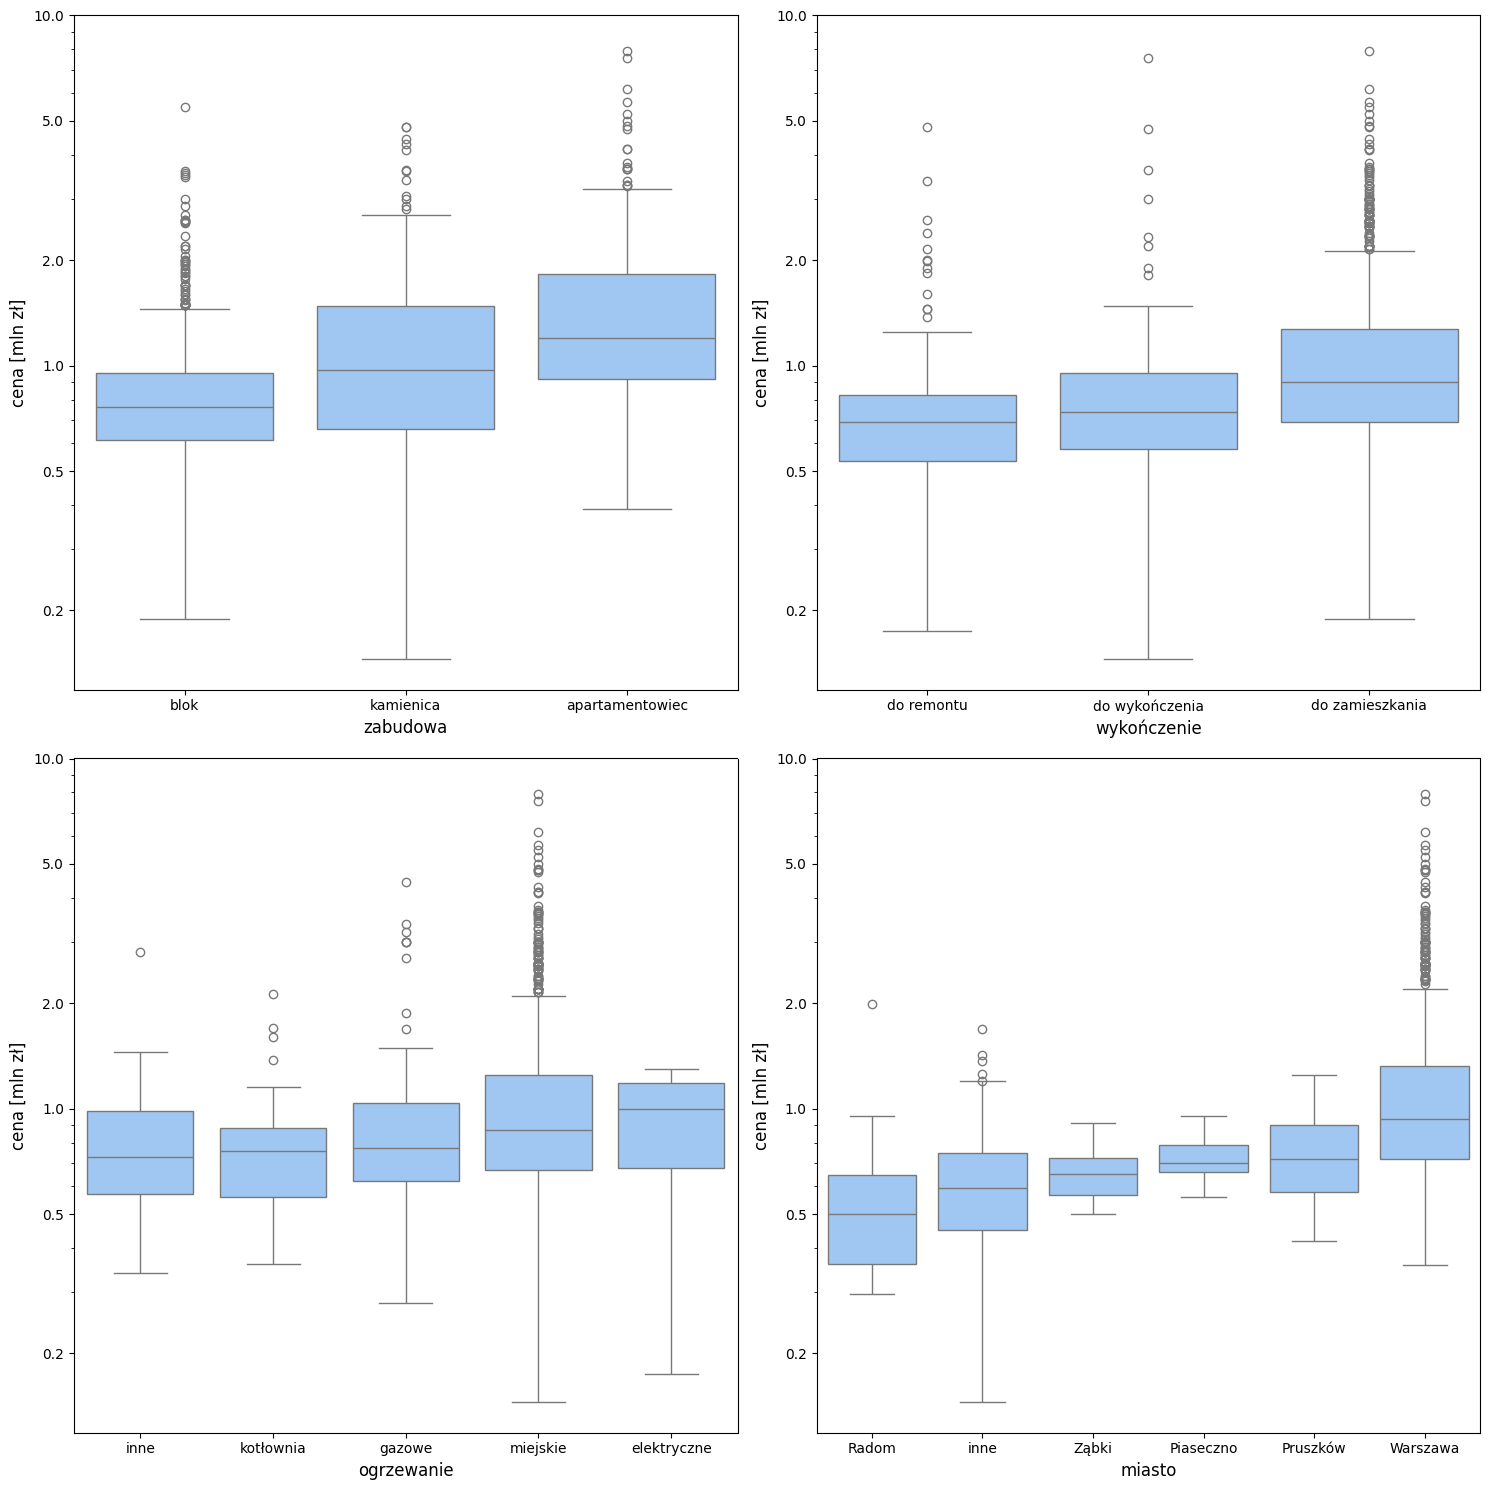

In [87]:
fig, ax = plt.subplots(2, 2, figsize=(15,15))
ax = ax.flatten()

boxplots(df, "zabudowa", 0)
boxplots(df, "wykończenie", 1)
boxplots(df, "ogrzewanie", 2)
boxplots(df, "miasto", 3)

plt.tight_layout()

Analizując zależność pomiędzy ceną a rodzajem zabudowy widzimy, że mieszkania o najwyższych, odstających cenach to apartamentowce. Ta kategoria charakteryzuje się też najwyższą medianą i największym rozstrzałem cenowym dla typowych ofert. Najtańszą i najstabilniejszą opcją są mieszkania w blokach. Pojawia się tutaj też najwięcej skrajnych wartości, co wynika jednak najprawdopodobniej z największej liczebności ofert. Kamienice znajdują się pośrodku stawki i nie wyróżniają się tak ekstremalnymi wahaniami cen.

W przypadku zależności pomiędzy ceną a stanem wykończenia, najwyższą medianą oraz największym rozstzałem cenowym charakteryzują się lokale gotowe do zamieszkania. Posiadają one również najwięcej wartości odstających oraz są one najbardziej skrajne. Jest to jednak jednocześnie najliczniejsza grupa. Najstabilniejszą cenowo opcją są mieszkania do remontu, które cechują się najniższą medianą. Lokale do wykończenia wykazują również podobną stabilność i niewiele wyższe ceny.

Jeśli chodzi o przedostatni wykres, widzimy, że mieszkania o najwyższych, skrajnie odstających cenach korzystają z ogrzewania miejskiego. Charakteryzuje się one również największą liczbą wartości skrajnych i dużym rozstrzałem cenowym. Ponownie jednak możemy to uzasadnić tym, że jest to najliczniejsza kategoria. Co ciekawe, pomimo, że ogrzewanie elektyczne było najmniej liczną grupą, cechuje się ono sporym rozstrzałem cenowym i ma wyższą medianę niż mieszkania z ogrzewaniem miejskim. Z kolei nieruchomości ogrzewane za pomocą kotłowni charakteryzują się najmniejszym rozstrzałem cenowym.

Na wykresie widać, że Warszawa dominuje pod względem mediany i rozstrzału cen, a także posiada najwięcej wartości odstających i są one najbardziej skrajne. Ciekawym zjawiskiem jest fakt, że Radom, jako drugie największe miasto na Mazowszu (oraz druga najliczniejsza kategoria), ma najniższą medianę cen i ustępuje pod tym względem o wiele mniejszym miejscowościom na obrzerzch stolicy. 

Wpływ rodzaju zabudowy na cenę jest znaczący - widać tutaj wyraźny skok mediany o ok. 0,4 mln zł, a same pudełka przesuwają się w górę i słabo na siebie nachodzą. Stan wykończenia ma o wiele mniejszy wpływ na ogólną cenę - mediana i wielkość dwóch pierwszych grup są bardzo zbliżone, jedynie kategoria *do zamieszkania* jest trochę droższa. Zmienna ogrzewanie również słabo tłumaczy zmienność ceny - mediany (z niewielkim skokiem w przypadku ogrzewania elektrycznego) i wysokości pudełek wszystkich pięciu grup są niemal identyczne. Natomiast jeśli chodzi o wpływ miasta na cenę, jest on bardziej znaczący - widać wzrost mediany od Radomia do Warszawy prawie o 0,5 mln zł, a same pudełka przesuwają się w górę i na siebie nie nachodzą.

##### **8.5 Wykresy pairplot dla najważniejszych zmiennych**

Na wykresie *pairplot* zestawiłam cenę z wybranymi zmiennymi objaśniającymi. Wybrałam powierzchnię, ponieważ wykazała ona najsilniejszą korelację liniową ze zmienną objaśnianą. Uwzględniłam również liczbę pokoi, ponieważ jako zmienna dyskretna pozwala spojrzeć na rozkład danych z innej perspektywy. Dodałam również odległość od centrum, ponieważ wykazała dla ceny ujemną, nielinową korelację. Wszystkie obserwacje zgrupowałam kolorystycznie względem rodzaju zabudowy.

<Figure size 3000x3000 with 0 Axes>

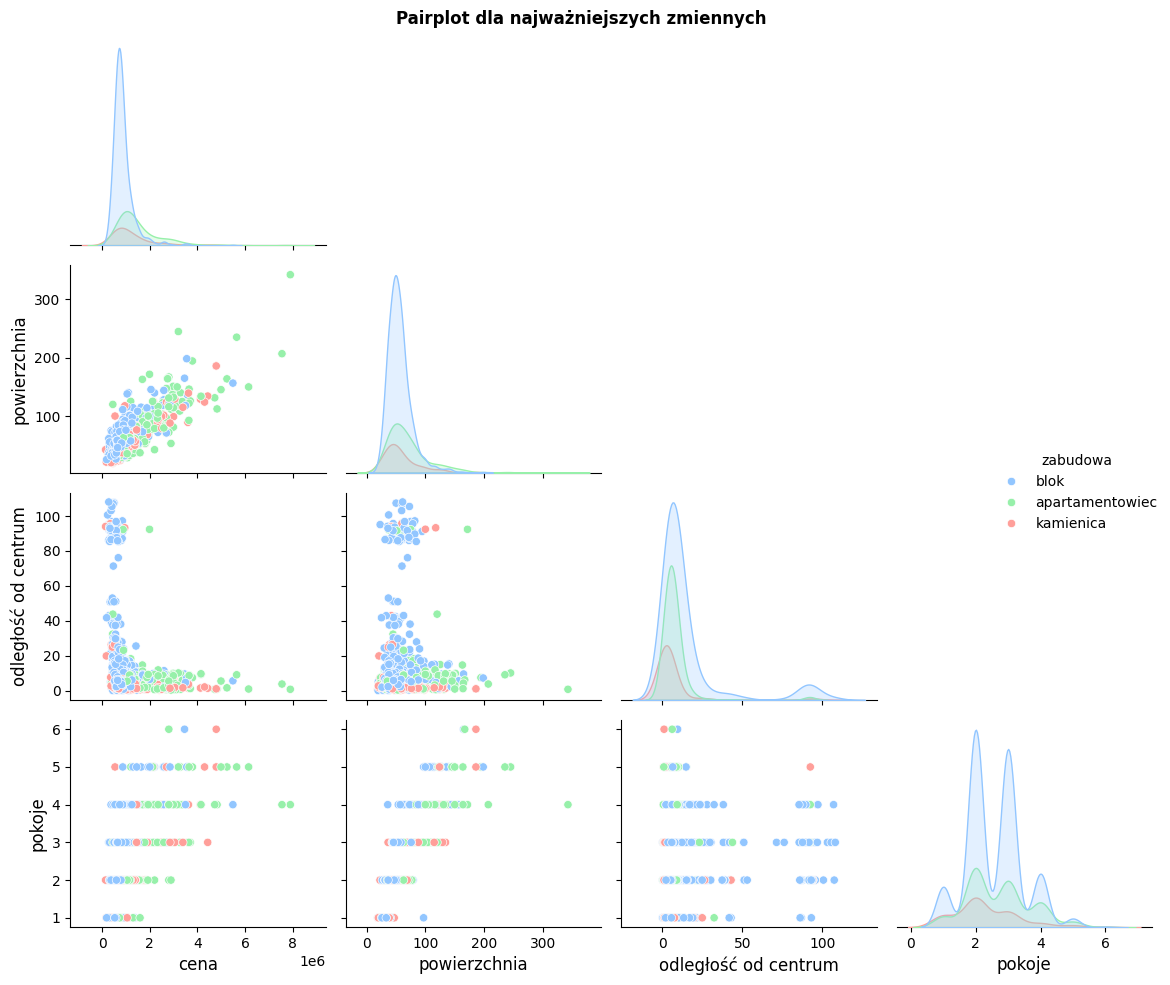

In [88]:
plt.figure(figsize=(30,30))
sns.pairplot(df, hue="zabudowa", vars=["cena","powierzchnia", "odległość od centrum", "pokoje"], height=2.5, corner=True)
plt.suptitle("Pairplot dla najważniejszych zmiennych", fontweight="bold")
plt.tight_layout()
plt.show()

Na początku warto przyjrzeć się diagonali wykresu. Dla każdego wykresu zdecydowanie dominują bloki, co nie jest jednak zaskoczeniem, ponieważ jest to najliczniejsza grupa w zbiorze. Warto zwrócić uwagę, że w przypadku odległości od centrum, w promieniu 80-100 km, czyli w większych mazowieckich miastach, kamienice i apartamentowce praktycznie znikają z rynku. Z kolei w przypadku liczby pokoi standardem są lokale pokojowe.

Na wykresie odległości od centrum i powierzchni widzimy, że nieruchomości mocno oddalone od Warszawy są stosunkowo nieduże i osiągają wielkości do $100m^2$. 

Zależności między liczbą pokoi a ceną oraz liczbą pokoi a powierzchnią wyglądają bardzo podobnie. Dokładna analiza punktów pokazuje jednak, że na rynku można znaleźć nieco tańsze mieszkania pięciopokojowe, które względem samej powierzchni wciąż pozostają bardzo duże. 

Z kolei patrząc na relację liczby pokoi i odległości od Warszawy, widać, że w dalszych rejonach Mazowsza buduje się lokale maksymalnie czteropokojowe.

#### **9. Przetwarzanie danych**

##### **9.1 Podział na zbiór treningowy i testowy**

In [89]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(df.iloc[:, 1:], df["cena"], test_size=0.2, random_state=42)

X_train

,powierzchnia,wiek,czynsz,pokoje,piętro,wysokość budynku,odległość od centrum,miasto,zabudowa,wykończenie,ogrzewanie
929,32.21,6.00,750.00,2.00,3.00,13.00,1.03,Warszawa,apartamentowiec,do zamieszkania,miejskie
699,60.50,15.00,1050.00,3.00,0.00,3.00,6.84,Warszawa,blok,do zamieszkania,miejskie
533,49.00,70.00,630.00,2.00,2.00,4.00,6.43,Warszawa,blok,do wykończenia,miejskie
411,46.80,9.00,700.00,2.00,2.00,6.00,4.61,Warszawa,blok,do wykończenia,miejskie
538,25.60,55.00,500.00,1.00,5.00,10.00,1.84,Warszawa,blok,do zamieszkania,miejskie
...,...,...,...,...,...,...,...,...,...,...,...
1055,56.00,16.00,700.00,2.00,0.00,3.00,13.15,Warszawa,blok,do zamieszkania,miejskie
1106,81.10,26.00,1447.00,3.00,3.00,15.00,3.52,Warszawa,blok,do zamieszkania,miejskie
1141,40.48,14.00,900.00,2.00,4.00,4.00,15.76,inne,blok,do wykończenia,kotłownia
870,49.00,58.00,784.24,3.00,6.00,10.00,4.28,Warszawa,blok,do zamieszkania,inne


##### **9.2**

In [90]:
from sklearn.base import BaseEstimator, TransformerMixin

class DivisionCreator(BaseEstimator, TransformerMixin):

    def __init__(self, new_column_name):
        self.new_column_name = new_column_name

    def fit(self, X, y=None):
        self.n_features_in_ = X.columns
        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            c1 = X.iloc[:, 0].values
            c2 = X.iloc[:, 1].values
        else:
            c1 = X[:, 0]
            c2 = X[:, 1]
        
        division = c1/c2
        
        return np.hstack([X, division.reshape(-1, 1)])

    def get_feature_names_out(self, input_features=None):
        if input_features:
            return list(input_features) + [self.new_column_name]
        return list(self.n_features_in_) + [self.new_column_name]
        

In [91]:
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import make_column_selector, ColumnTransformer
from sklearn.pipeline import Pipeline

scaler = RobustScaler()
ohe = OneHotEncoder(sparse_output=False)

pipe = Pipeline(steps=[
    ("Feature engeneering", ColumnTransformer(
        transformers = [
            ("Division", 
             DivisionCreator("metraż na pokój"), 
             ["powierzchnia", "pokoje"])
        ],
        verbose_feature_names_out=False,
        remainder="passthrough"
    )),
    
    ("Scaling", ColumnTransformer(
        transformers = [
            ("num", 
             scaler, 
             make_column_selector(dtype_include=np.number)),
            ("cat",
             ohe, 
             make_column_selector(dtype_include=object))
        ],
        verbose_feature_names_out=False
    ))]).set_output(transform="pandas")

In [92]:
X_train_transformed = pipe.fit_transform(X_train)
X_train_transformed

,powierzchnia,pokoje,metraż na pokój,wiek,czynsz,piętro,wysokość budynku,odległość od centrum,miasto_Piaseczno,miasto_Pruszków,...,zabudowa_blok,zabudowa_kamienica,wykończenie_do remontu,wykończenie_do wykończenia,wykończenie_do zamieszkania,ogrzewanie_elektryczne,ogrzewanie_gazowe,ogrzewanie_inne,ogrzewanie_kotłownia,ogrzewanie_miejskie
929,-0.83,0.00,-0.92,-0.44,-0.16,0.33,2.00,-0.85,0.00,0.00,...,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00
699,0.26,1.00,-0.33,-0.24,0.51,-0.67,-0.50,0.07,0.00,0.00,...,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00
533,-0.18,0.00,0.30,0.98,-0.42,0.00,-0.25,0.01,0.00,0.00,...,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00
411,-0.27,0.00,0.14,-0.38,-0.27,0.00,0.25,-0.28,0.00,0.00,...,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00
538,-1.08,-1.00,0.46,0.64,-0.71,1.00,1.25,-0.72,0.00,0.00,...,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1055,0.09,0.00,0.81,-0.22,-0.27,-0.67,-0.50,1.07,0.00,0.00,...,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00
1106,1.05,1.00,0.67,0.00,1.40,0.33,2.50,-0.45,0.00,0.00,...,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00
1141,-0.51,0.00,-0.32,-0.27,0.18,0.67,-0.25,1.49,0.00,0.00,...,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00
870,-0.18,1.00,-0.89,0.71,-0.08,1.33,1.25,-0.33,0.00,0.00,...,1.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00


In [93]:
X_test_transformed = pipe.transform(X_test)
X_test_transformed

,powierzchnia,pokoje,metraż na pokój,wiek,czynsz,piętro,wysokość budynku,odległość od centrum,miasto_Piaseczno,miasto_Pruszków,...,zabudowa_blok,zabudowa_kamienica,wykończenie_do remontu,wykończenie_do wykończenia,wykończenie_do zamieszkania,ogrzewanie_elektryczne,ogrzewanie_gazowe,ogrzewanie_inne,ogrzewanie_kotłownia,ogrzewanie_miejskie
418,-0.39,0.00,-0.09,0.07,-0.52,0.00,-0.25,-0.21,0.00,0.00,...,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00
260,0.44,0.00,1.48,-0.33,-0.09,0.33,-0.50,0.20,0.00,0.00,...,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00
333,-0.89,-1.00,1.19,-0.42,-0.09,0.67,0.25,-0.70,0.00,0.00,...,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00
628,1.07,1.00,0.69,-0.47,0.21,0.33,-0.50,1.52,0.00,0.00,...,1.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00
101,-0.37,0.00,-0.06,0.44,-0.26,1.33,2.50,-0.05,0.00,0.00,...,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
655,-0.09,0.00,0.47,-0.29,0.00,0.00,0.25,-0.24,0.00,0.00,...,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00
987,-0.67,-1.00,2.00,-0.11,0.40,9.33,6.25,-0.82,0.00,0.00,...,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00
178,-0.30,0.00,0.08,0.38,-0.04,0.00,1.25,-0.04,0.00,0.00,...,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00
31,-1.30,-1.00,-0.37,0.78,-1.19,1.67,1.75,-0.19,0.00,0.00,...,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00
